# Paper agent baseline

Minimal single-agent baseline imported from `urbanomy.methods.agent`.


In [ ]:
from urbanomy.methods.agent import init_llm
import pandas as pd

llm = init_llm("deepseek/deepseek-v4-flash")


In [5]:
from urbanomy.methods.agent import SingleAgentBaseline

task = "Город Санкт-Петербург. � азработай план уплотнения городского центра."

baseline = SingleAgentBaseline(llm=llm)
state = baseline.invoke_state(task)


In [6]:
print(state["output"])


Разработка плана уплотнения исторического центра Санкт-Петербурга — сложнейшая градостроительная задача, балансирующая на грани сохранения наследия ЮНЕСКО и необходимости развития. Ниже представлен концептуальный план, разделенный на ключевые направления.

### 1. Ключевой принцип: "Никакого точечного уплотнения"

Уплотнение центра должно происходить не за счет сноса исторических зданий или строительства в дворовых колодцах (джентрификация с потерей идентичности), а за счет:

- **Реконструкции и реновации аварийного фонда** с повышением этажности вглубь квартала (при сохранении исторических фасадов-стен).
- **Освоения "серого пояса"** — бывших промышленных зон и железнодорожных путей, примыкающих к центру.
- **Подземной урбанистики.**

### 2. Конкретные направления реализации

#### А. Уплотнение за счет "второго яруса" (надстройка/мансарды)
- **Цель:** Увеличение жилой площади без изменения пятна застройки.
- **План:**
    - Разрешить надстройку мансардных этажей на зданиях, где это не 

In [4]:
# state["log"]


In [ ]:
import geopandas as gpd

basline_blocks = gpd.read_file('data/traning_data/gatchina_baseline.geojson')
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,id,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,30.0,836277.821580,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,1,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,2275.0,302985.560227,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,2,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,3,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,4,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [8]:
basline_blocks.loc[142]

residential                                                         1.0
business                                                            0.0
recreation                                                          0.0
industrial                                                          0.0
transport                                                           0.0
special                                                             0.0
agriculture                                                         0.0
land_use                                            LandUse.RESIDENTIAL
share                                                               1.0
footprint_area                                              1568.375787
build_floor_area                                            1568.375787
living_area                                                 1202.729596
non_living_area                                              365.646192
population                                                      

In [ ]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model('data/catboost_land_value_no_services.cbm')  # модель на лог-цене
print(len(model.feature_names_))

101


In [11]:
feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]
basline_blocks["id"] = basline_blocks.index

In [12]:
basline_blocks['residential'] = basline_blocks['residential'].astype('float64')

In [10]:
# import geopandas as gpd
# import pandas as pd

# # 1. Переводим в метрическую CRS
# baseline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()

# # 2. Считаем площадь в м2 и гектарах
# baseline_blocks_metric["calc_area_m2"] = baseline_blocks_metric.geometry.area
# baseline_blocks_metric["calc_area_ha"] = baseline_blocks_metric["calc_area_m2"] / 10_000

# # 3. Переводим site_area в гектары
# baseline_blocks_metric["site_area_ha"] = baseline_blocks_metric["site_area"] / 10_000

# # 4. Сравниваем
# baseline_blocks_metric["area_diff_ha"] = (
#     baseline_blocks_metric["calc_area_ha"] - baseline_blocks_metric["site_area_ha"]
# )

# baseline_blocks_metric["area_diff_pct"] = (
#     baseline_blocks_metric["area_diff_ha"] / baseline_blocks_metric["site_area_ha"] * 100
# )

# # 5. Сводка
# print(
#     baseline_blocks_metric[
#         ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct"]
#     ].describe()
# )

# # 6. Самые большие расхождения
# comparison_ha = baseline_blocks_metric[
#     ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct", "geometry"]
# ].copy()

# comparison_ha["abs_area_diff_pct"] = comparison_ha["area_diff_pct"].abs()
# comparison_ha.sort_values("abs_area_diff_pct", ascending=False).head(10)


In [13]:
# удаляем старую колонку
basline_blocks = basline_blocks.drop(columns=["site_area"], errors="ignore").copy()

# пересчитываем площадь в метрической CRS
basline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()
basline_blocks["site_area"] = basline_blocks_metric.geometry.area.values


In [14]:
from urbanomy.methods.land_value_modeling import LandPriceEstimator

estimator = LandPriceEstimator(
    model=model,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,fsi,gsi,mxi,l,morphotype,area_accessibility,id,geometry,site_area,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",215420.389645,4.523965e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,1,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",108166.972589,6.273598e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,2,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",77911.495727,5.809435e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,3,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",32058.270586,1.065881e+08
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,4,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",30779.356283,8.802486e+07


count       333.000000
mean     362550.398065
std      166120.451087
min           0.000000
25%      192695.695235
50%      411948.014838
75%      501687.185946
max      642932.168889
Name: land_value_per_100m2, dtype: float64


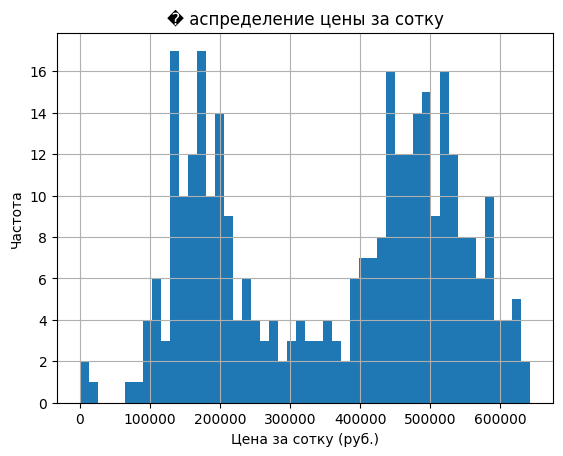

In [15]:
import numpy as np
import matplotlib.pyplot as plt
# 1) Цена за сотку (100 м²)
blocks_pred["land_value_per_100m2"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred = blocks_pred.replace([np.inf, -np.inf], np.nan)
blocks_pred = blocks_pred.fillna(0)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["land_value_per_100m2"].quantile(0.95)
blocks_clean = blocks_pred[blocks_pred["land_value_per_100m2"] <= p99].copy()

print(blocks_clean["land_value_per_100m2"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["land_value_per_100m2"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("� аспределение цены за сотку")
plt.show()



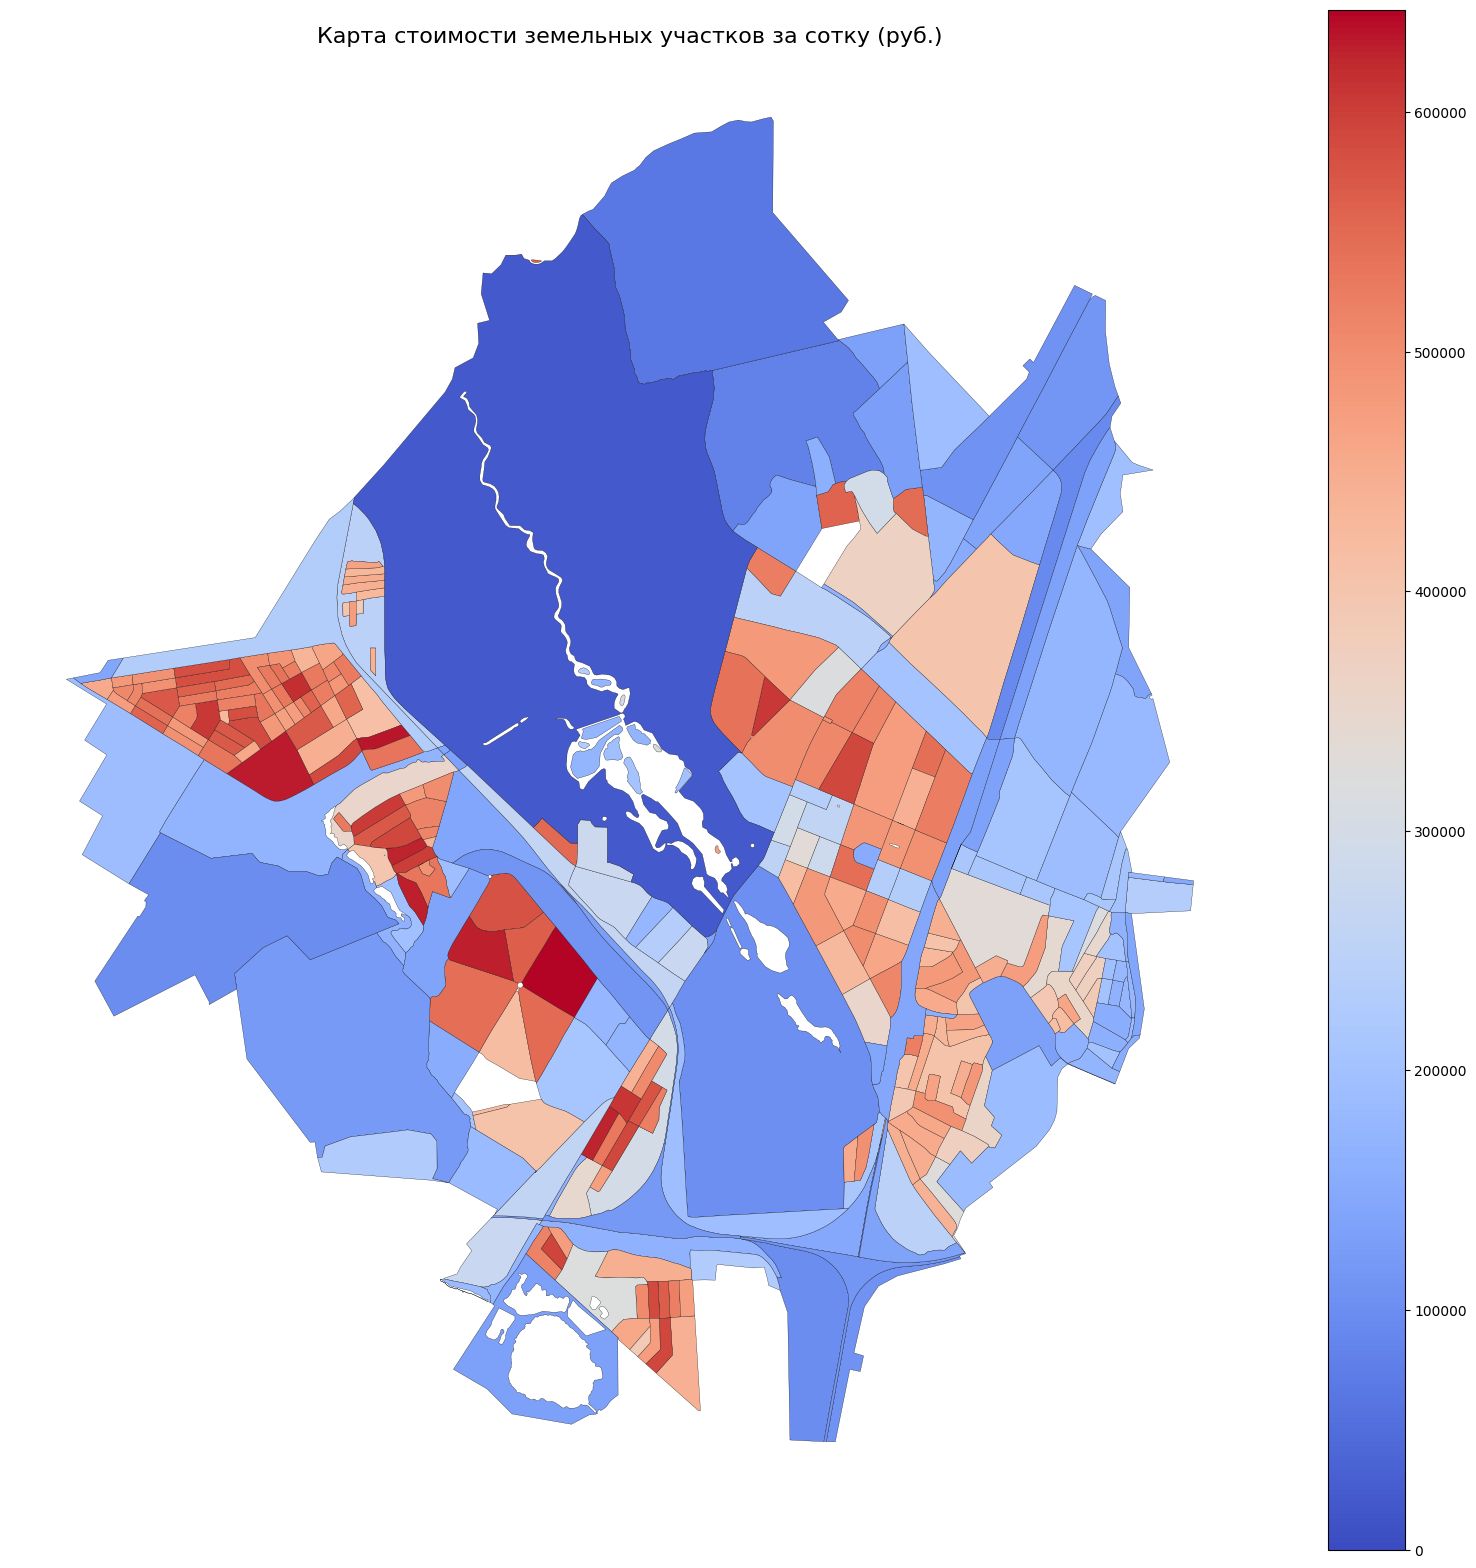

In [16]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value_per_100m2',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков за сотку (руб.)', fontsize=16)

plt.show()

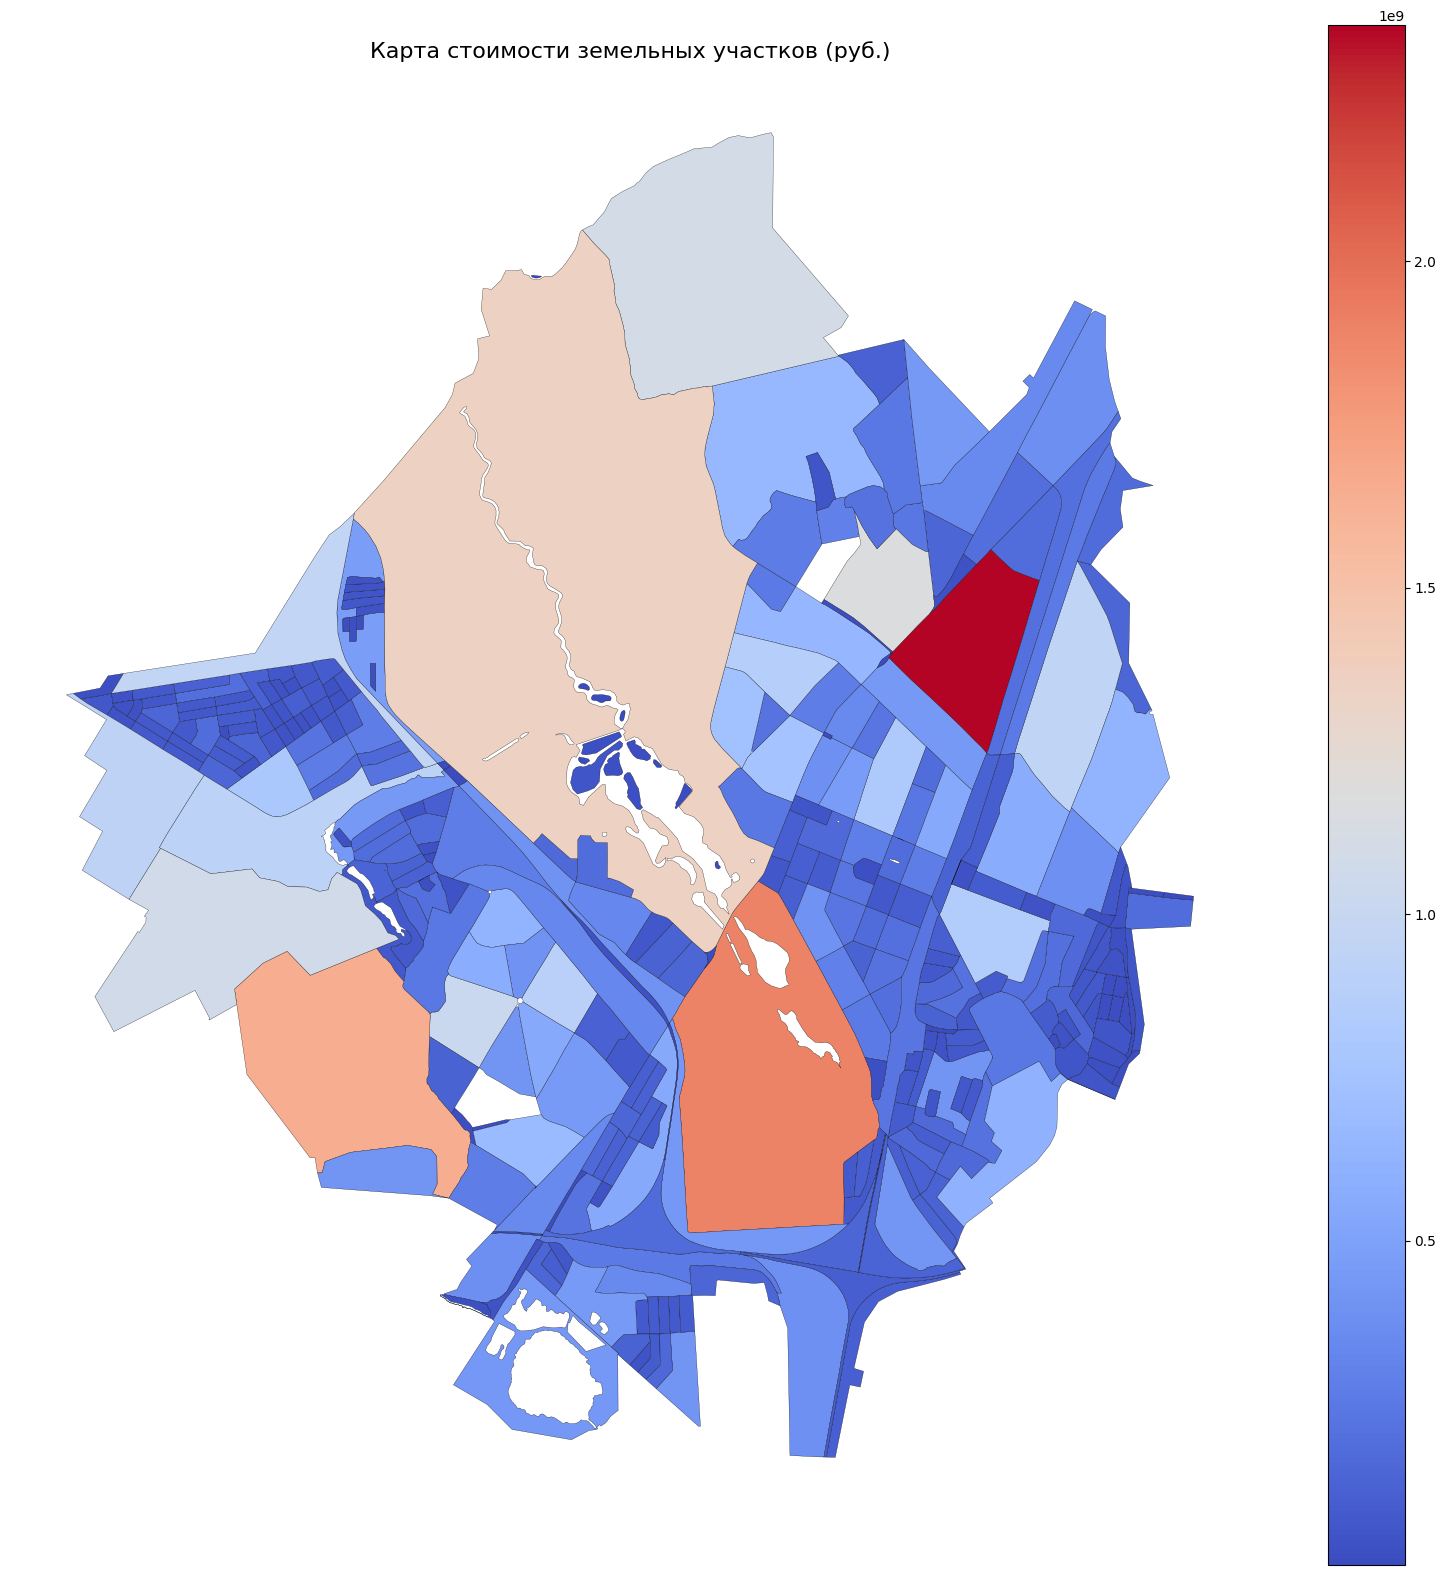

In [17]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков (руб.)', fontsize=16)

plt.show()

# Выбор сценария развития

In [18]:
blocks_clean["id"] = blocks_clean.index

In [19]:
target_id = 86

/var/folders/yl/0swqblhn58d982w93b_6pg1w0000gn/T/ipykernel_83315/4044864446.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)


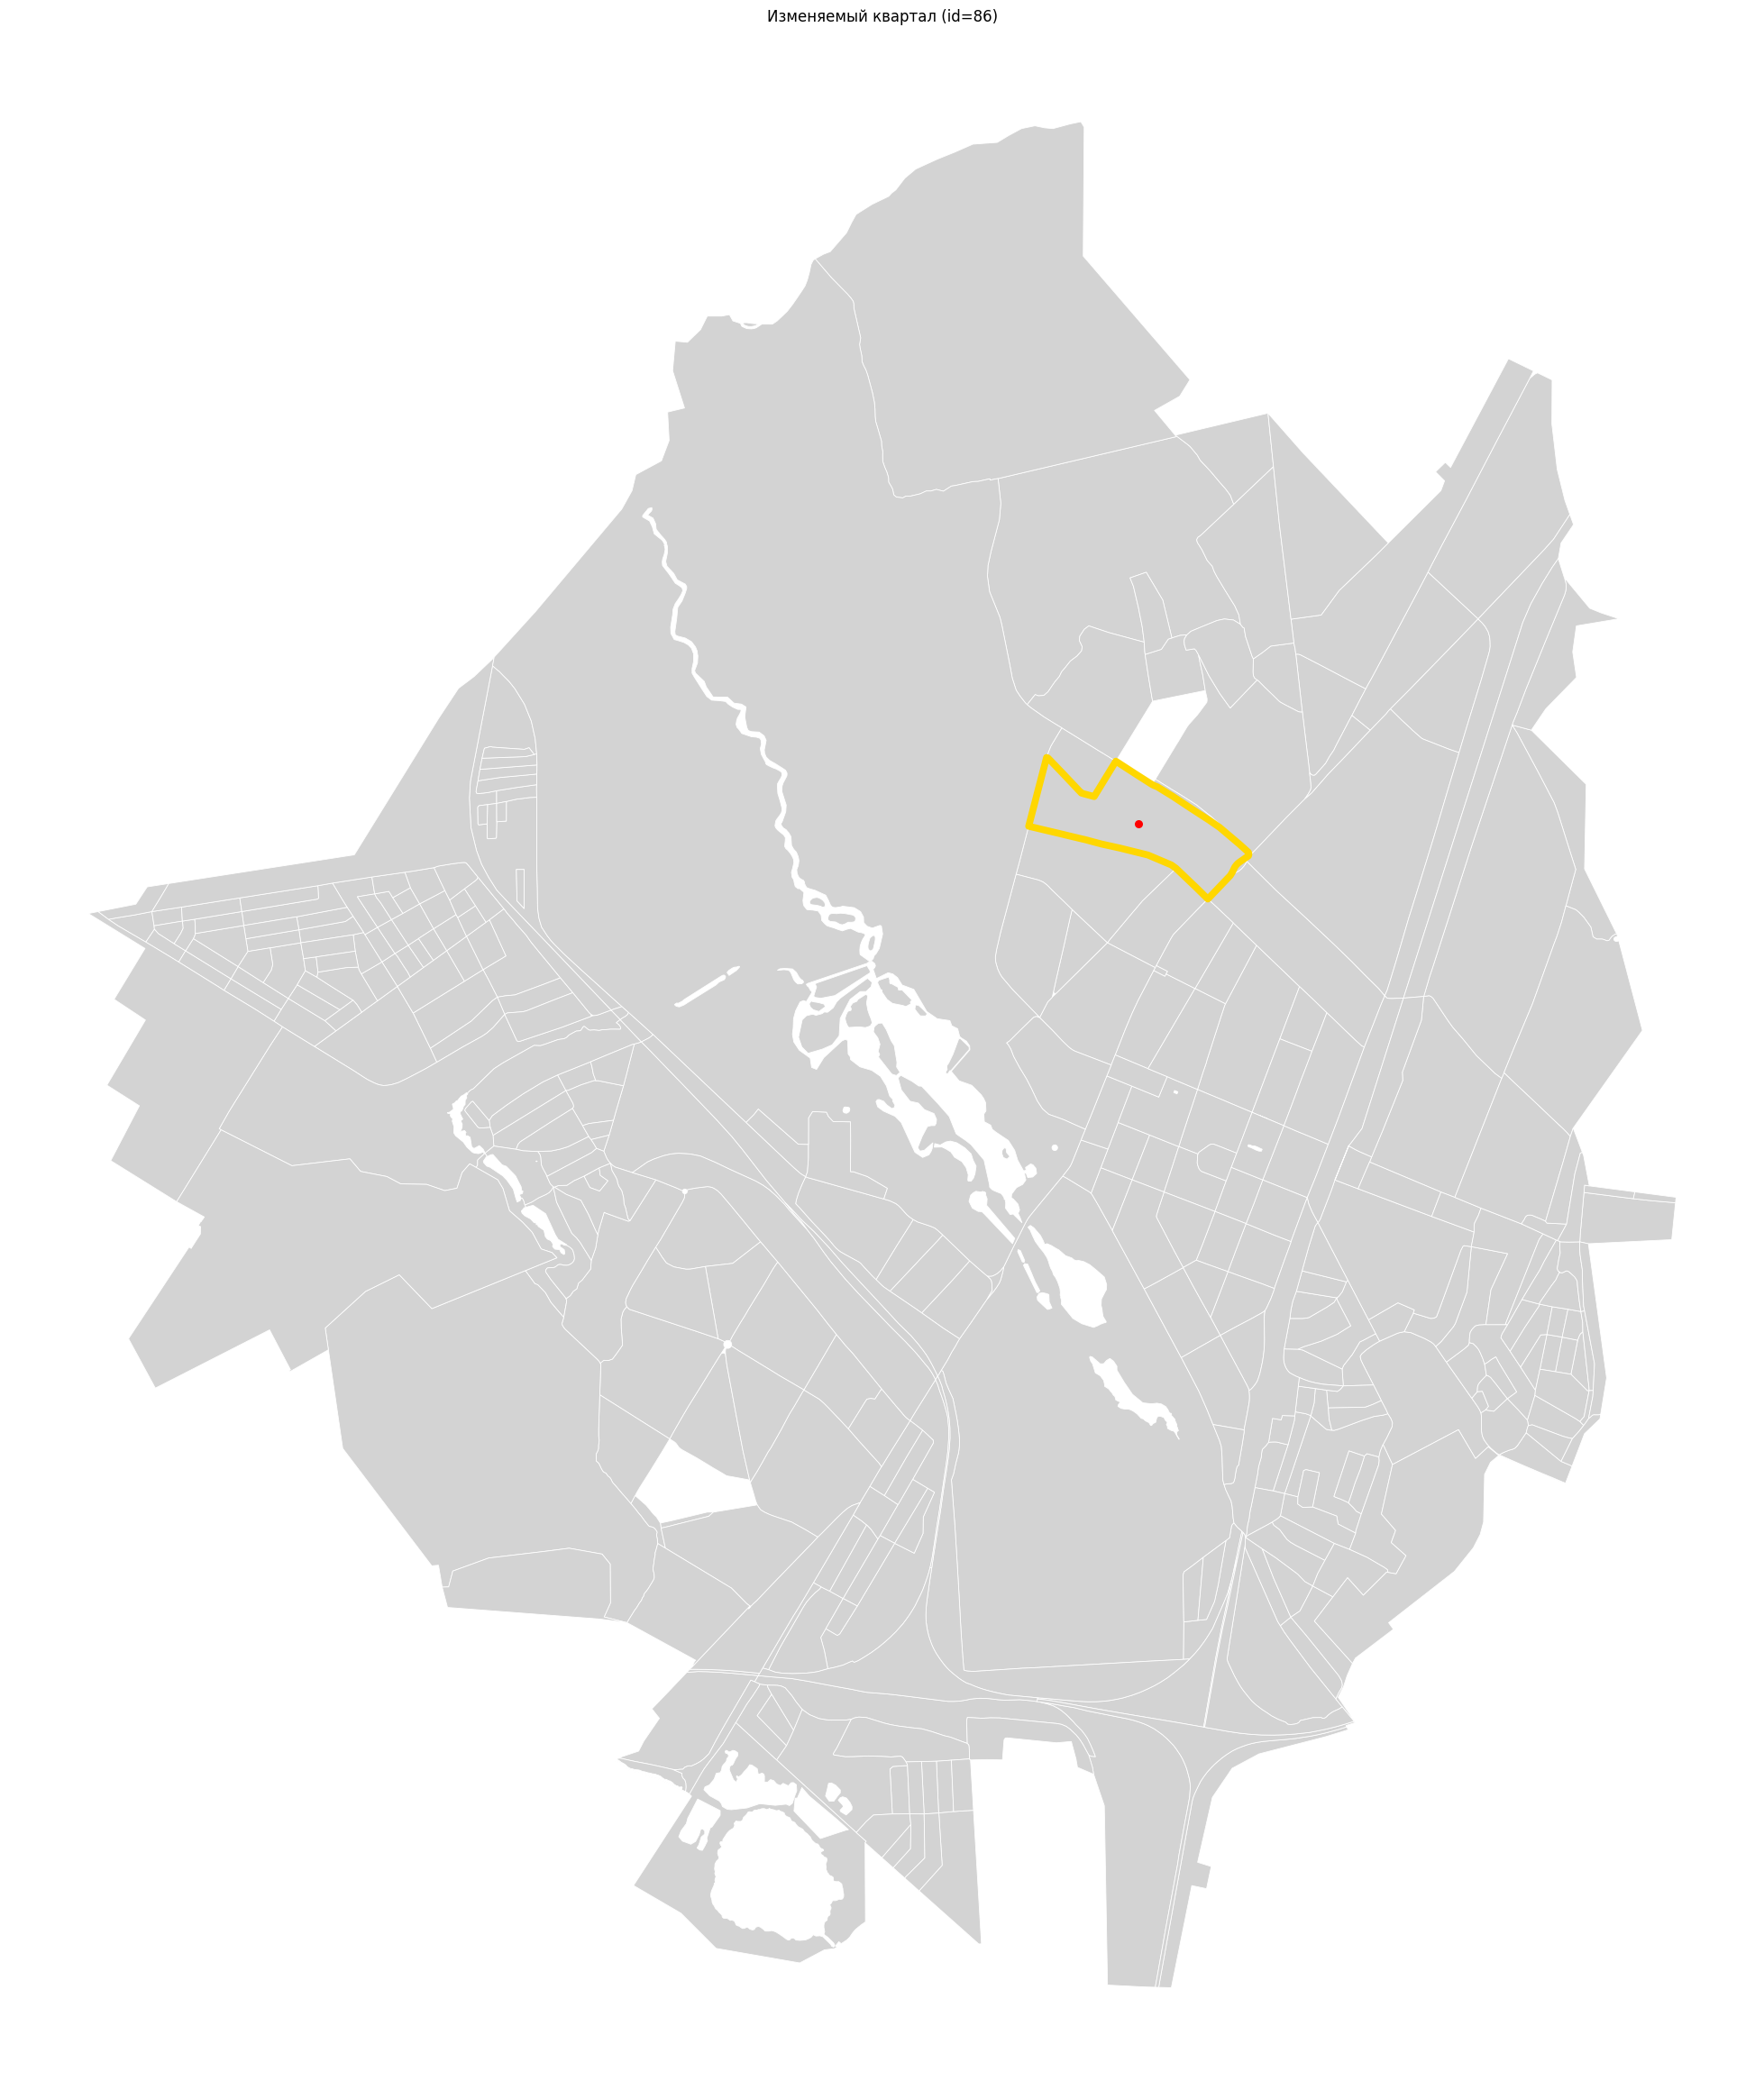

In [20]:
import matplotlib.pyplot as plt

target_id = 86
target_block = blocks_clean.loc[blocks_clean["id"] == target_id]

fig, ax = plt.subplots(figsize=(25, 35))
blocks_clean.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)
target_block.plot(ax=ax, color="none", edgecolor="gold", linewidth=5.5)
target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)

ax.set_title(f"Изменяемый квартал (id={target_id})")
ax.axis("off")
plt.show()


In [19]:
# blocks_after.to_file('./data/test/gatchina_RESIDENTIAL.geojson', driver='GeoJSON')

# Проверка стабильности модели по Гатчине

In [22]:
from langchain_ollama import ChatOllama
llm = ChatOllama(model="llama3", base_url="http://localhost:11434")

In [78]:
from urbanomy.methods.agent import init_llm

llm = init_llm("deepseek/deepseek-v4-flash")

In [79]:
llm.invoke('Привет')

AIMessage(content='Привет! Рад тебя видеть. Я DeepSeek — твой искусственный помощник. Чем могу помочь? Можешь задать любой вопрос, попросить что-то написать, объяснить, перевести или просто поболтать. 😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 227, 'prompt_tokens': 6, 'total_tokens': 233, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 168, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'c977ef86-9443-49f2-96e8-101889a88184', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ef6cd-b882-7850-962c-9cbf9faf24c3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 227, 'total_tokens': 233, 'input_token_details': {'cache_read': 0}, 'ou

In [80]:
baseline = SingleAgentBaseline(llm=llm)

In [ ]:
import json
from pathlib import Path
import pandas as pd


In [81]:
prompts = ['Оцени представленный сценарий по критерию социальной инклюзивности и риска вытеснения. Определи, сохраняет ли сценарий социальное и функциональное разнообразие территории, доступность повседневных сервисов и возможности для уязвимых групп пользователей. Оцени от 0 до 1, в ответе укажи только число',
           'Оцени представленный сценарий по критерию стратегической уместности для долгосрочного развития города и района. Учти компактность и полицентричность развития, смешанность функций, баланс жилья, рабочих мест и сервисов, а также способность территории адаптироваться к будущим изменениям. Оцени от 0 до 1, в ответе укажи только число',
           'Оцени представленный сценарий по его способности создавать условия для активной городской жизни. Учти смешанность функций, потенциал активных первых этажей, пешеходную доступность, наличие общественных пространств и разнообразие повседневных сценариев использования территории в течение дня и вечера. Оцени от 0 до 1, в ответе укажи только число',
           'Оцени представленный сценарий по критерию согласованности интересов различных пользователей территории. Проанализируй возможные конфликты между жителями, пешеходами, автомобилистами, предпринимателями, посетителями, работниками, пожилыми людьми и семьями с детьми. Оцени от 0 до 1, в ответе укажи только число',
           'Оцени представленный сценарий по критерию экологической и инфраструктурной устойчивости. Учти плотность застройки, транспортную и инфраструктурную нагрузку, ресурсную эффективность, экологические последствия и возможность поэтапной адаптации территории. Оцени от 0 до 1, в ответе укажи только число']

In [82]:


from tqdm.auto import tqdm

# Путь сохранения результата (локально в папке с ноутбуком)
notebook_dir = Path('examples') if Path('examples/paper.ipynb').exists() else Path('.')
out_path = notebook_dir / 'goals_evaluation_deepseek.csv'

results = []

# Для каждого квартала выполняем оценку по каждому промпту
for index, row in tqdm(
    blocks_clean.iterrows(),
    total=len(blocks_clean),
    desc="Оценка кварталов"
):
    # безопасно получить id квартала
    block_id = int(row['id']) if 'id' in row.index else int(index)

    # короткий контекст для промпта — берём все поля
    ctx_keys = blocks_clean.columns.tolist()
    ctx = {}

    for k in ctx_keys:
        if k in row.index and pd.notnull(row[k]):
            value = row[k]

            if isinstance(value, (int, float)):
                ctx[k] = float(value)
            else:
                ctx[k] = str(value)

    for prompt in prompts:
        task = f"{prompt}\n\nКонтекст района (id={block_id}): {ctx}"

        try:
            state = baseline.invoke_state(task)

            if isinstance(state, dict):
                output = (
                    state.get('output')
                    if 'output' in state
                    else json.dumps(state, ensure_ascii=False)
                )
            else:
                output = str(state)

        except Exception as e:
            output = f'ERROR: {e}'

        results.append({
            'id': block_id,
            'prompt': prompt,
            'output': output,
        })

eval_df = pd.DataFrame(results)

eval_df.to_csv(
    out_path,
    index=False,
    encoding='utf-8'
)

eval_df.head()

Оценка кварталов:   0%|          | 0/333 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [83]:
eval_df = pd.DataFrame(results)
eval_df  

,id,prompt,output
0,0,Оцени представленный сценарий по критерию соци...,0.3
1,0,Оцени представленный сценарий по критерию стра...,0.2
2,0,Оцени представленный сценарий по его способнос...,0.2
3,0,Оцени представленный сценарий по критерию согл...,0.6
4,0,Оцени представленный сценарий по критерию экол...,0.2
...,...,...,...
950,195,Оцени представленный сценарий по критерию соци...,0.6
951,195,Оцени представленный сценарий по критерию стра...,0.2
952,195,Оцени представленный сценарий по его способнос...,0.3
953,195,Оцени представленный сценарий по критерию согл...,0.7


In [84]:
eval_df.to_csv('goals_evaluation_deepseek.csv')

In [91]:
pd.read_csv('goals_evaluation_deepseek.csv')

,Unnamed: 0,id,prompt,output
0,0,0,Оцени представленный сценарий по критерию соци...,0.3
1,1,0,Оцени представленный сценарий по критерию стра...,0.2
2,2,0,Оцени представленный сценарий по его способнос...,0.2
3,3,0,Оцени представленный сценарий по критерию согл...,0.6
4,4,0,Оцени представленный сценарий по критерию экол...,0.2
...,...,...,...,...
950,950,195,Оцени представленный сценарий по критерию соци...,0.6
951,951,195,Оцени представленный сценарий по критерию стра...,0.2
952,952,195,Оцени представленный сценарий по его способнос...,0.3
953,953,195,Оцени представленный сценарий по критерию согл...,0.7


In [86]:
eval_df['output_clean'] = pd.to_numeric(

    eval_df['output'],

    errors='coerce'

)

In [87]:
blocks_evaluated = blocks_clean.merge(
    eval_df,
    left_on='id',
    right_on='id',
    how='left'
)
blocks_evaluated.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,morphotype,area_accessibility,id,geometry,site_area,land_value,land_value_per_100m2,prompt,output,output_clean
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,individual residential,10.063987,0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",215420.389645,4.523965e+08,210006.365794,Оцени представленный сценарий по критерию соци...,0.3,0.3
1,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,individual residential,10.063987,0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",215420.389645,4.523965e+08,210006.365794,Оцени представленный сценарий по критерию стра...,0.2,0.2
2,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,individual residential,10.063987,0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",215420.389645,4.523965e+08,210006.365794,Оцени представленный сценарий по его способнос...,0.2,0.2
3,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,individual residential,10.063987,0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",215420.389645,4.523965e+08,210006.365794,Оцени представленный сценарий по критерию согл...,0.6,0.6
4,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,individual residential,10.063987,0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",215420.389645,4.523965e+08,210006.365794,Оцени представленный сценарий по критерию экол...,0.2,0.2


In [88]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from catboost import Pool

def plot_catboost_shap(model, X, cat_features=None, top_n=20):

    """

    SHAP importance для CatBoost с поддержкой категориальных признаков.

    """

    # Создаем Pool

    pool = Pool(

        data=X,

        cat_features=cat_features

    )

    # SHAP values

    shap_values = model.get_feature_importance(

        data=pool,

        type="ShapValues"

    )

    # последний столбец = expected value

    shap_values = shap_values[:, :-1]

    # важность признаков

    shap_importance = pd.DataFrame({

        "feature": X.columns,

        "importance": np.abs(shap_values).mean(axis=0)

    })

    shap_importance = (

        shap_importance

        .sort_values("importance", ascending=False)

        .head(top_n)

    )

    # график

    plt.figure(figsize=(10, 6))

    plt.barh(

        shap_importance["feature"][::-1],

        shap_importance["importance"][::-1]

    )

    plt.xlabel("Mean |SHAP value|")

    plt.ylabel("Feature")

    plt.title(f"Top-{top_n} SHAP importance")

    plt.tight_layout()

    plt.show()

    return shap_importance

Learning rate set to 0.03152
0:	learn: 0.1747483	total: 1.69ms	remaining: 1.68s
100:	learn: 0.1037756	total: 82.4ms	remaining: 734ms
200:	learn: 0.0818355	total: 141ms	remaining: 562ms
300:	learn: 0.0655030	total: 191ms	remaining: 444ms
400:	learn: 0.0518001	total: 249ms	remaining: 373ms
500:	learn: 0.0431202	total: 303ms	remaining: 302ms
600:	learn: 0.0355413	total: 357ms	remaining: 237ms
700:	learn: 0.0293064	total: 406ms	remaining: 173ms
400:	learn: 0.0518001	total: 249ms	remaining: 373ms
500:	learn: 0.0431202	total: 303ms	remaining: 302ms
600:	learn: 0.0355413	total: 357ms	remaining: 237ms
700:	learn: 0.0293064	total: 406ms	remaining: 173ms
800:	learn: 0.0247909	total: 457ms	remaining: 114ms
900:	learn: 0.0211126	total: 511ms	remaining: 56.1ms
999:	learn: 0.0179296	total: 562ms	remaining: 0us
800:	learn: 0.0247909	total: 457ms	remaining: 114ms
900:	learn: 0.0211126	total: 511ms	remaining: 56.1ms
999:	learn: 0.0179296	total: 562ms	remaining: 0us


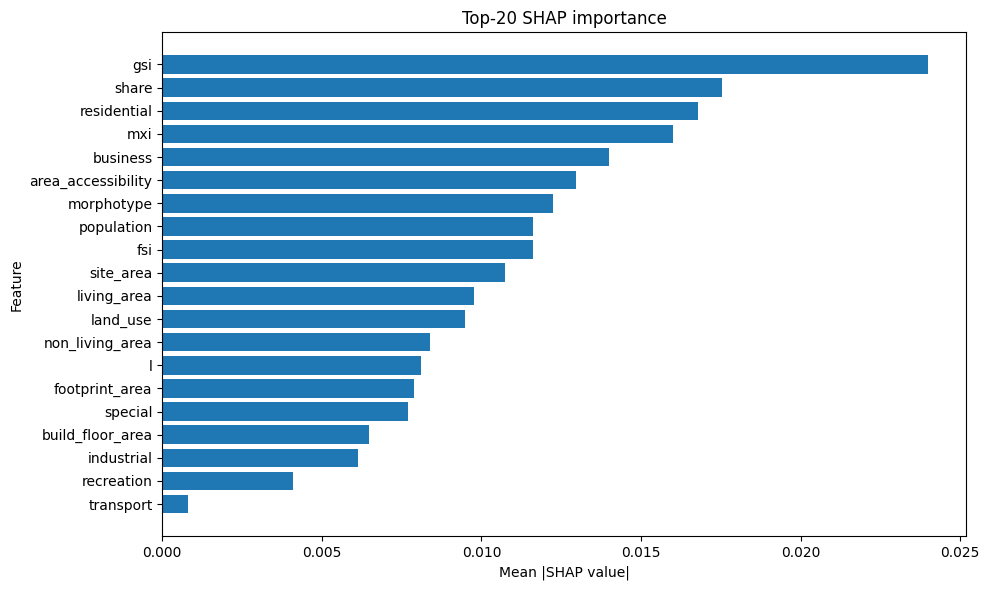

Learning rate set to 0.03152
0:	learn: 0.1081381	total: 868us	remaining: 868ms
100:	learn: 0.0519538	total: 56.1ms	remaining: 499ms
200:	learn: 0.0401465	total: 108ms	remaining: 431ms
300:	learn: 0.0320868	total: 159ms	remaining: 369ms
400:	learn: 0.0256784	total: 210ms	remaining: 314ms
500:	learn: 0.0211788	total: 259ms	remaining: 258ms
600:	learn: 0.0174038	total: 309ms	remaining: 205ms
700:	learn: 0.0144815	total: 361ms	remaining: 154ms
400:	learn: 0.0256784	total: 210ms	remaining: 314ms
500:	learn: 0.0211788	total: 259ms	remaining: 258ms
600:	learn: 0.0174038	total: 309ms	remaining: 205ms
700:	learn: 0.0144815	total: 361ms	remaining: 154ms
800:	learn: 0.0119743	total: 418ms	remaining: 104ms
900:	learn: 0.0100711	total: 473ms	remaining: 52ms
999:	learn: 0.0086629	total: 527ms	remaining: 0us
800:	learn: 0.0119743	total: 418ms	remaining: 104ms
900:	learn: 0.0100711	total: 473ms	remaining: 52ms
999:	learn: 0.0086629	total: 527ms	remaining: 0us


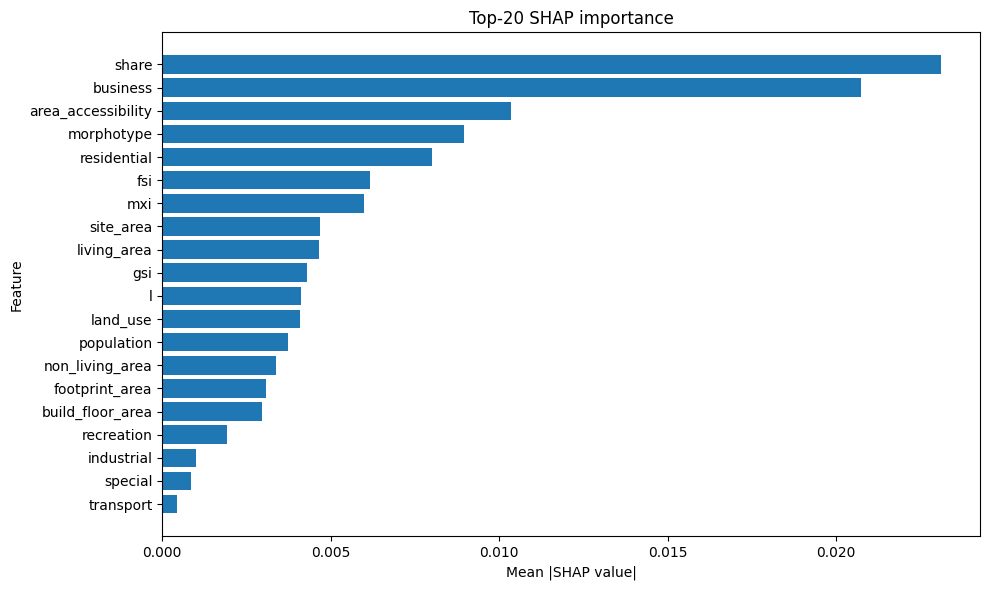

Learning rate set to 0.03152
0:	learn: 0.1347497	total: 637us	remaining: 637ms
100:	learn: 0.0588486	total: 60.8ms	remaining: 541ms
200:	learn: 0.0442050	total: 113ms	remaining: 449ms
300:	learn: 0.0353728	total: 168ms	remaining: 390ms
400:	learn: 0.0285445	total: 224ms	remaining: 335ms
500:	learn: 0.0237340	total: 280ms	remaining: 279ms
600:	learn: 0.0197176	total: 331ms	remaining: 220ms
700:	learn: 0.0164529	total: 382ms	remaining: 163ms
400:	learn: 0.0285445	total: 224ms	remaining: 335ms
500:	learn: 0.0237340	total: 280ms	remaining: 279ms
600:	learn: 0.0197176	total: 331ms	remaining: 220ms
700:	learn: 0.0164529	total: 382ms	remaining: 163ms
800:	learn: 0.0137671	total: 433ms	remaining: 108ms
900:	learn: 0.0115011	total: 488ms	remaining: 53.7ms
999:	learn: 0.0097257	total: 543ms	remaining: 0us
800:	learn: 0.0137671	total: 433ms	remaining: 108ms
900:	learn: 0.0115011	total: 488ms	remaining: 53.7ms
999:	learn: 0.0097257	total: 543ms	remaining: 0us


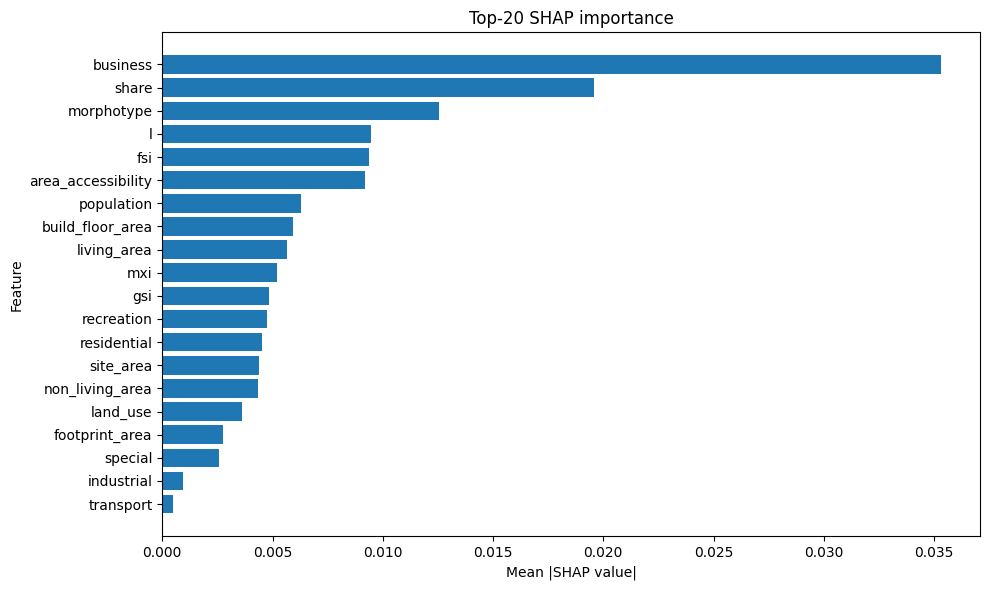

Learning rate set to 0.03152
0:	learn: 0.2704023	total: 556us	remaining: 556ms
100:	learn: 0.2022863	total: 52.1ms	remaining: 463ms
200:	learn: 0.1669871	total: 101ms	remaining: 402ms
300:	learn: 0.1400740	total: 151ms	remaining: 352ms
400:	learn: 0.1140512	total: 202ms	remaining: 301ms
500:	learn: 0.0947071	total: 253ms	remaining: 252ms
600:	learn: 0.0792710	total: 304ms	remaining: 202ms
700:	learn: 0.0661227	total: 356ms	remaining: 152ms
400:	learn: 0.1140512	total: 202ms	remaining: 301ms
500:	learn: 0.0947071	total: 253ms	remaining: 252ms
600:	learn: 0.0792710	total: 304ms	remaining: 202ms
700:	learn: 0.0661227	total: 356ms	remaining: 152ms
800:	learn: 0.0552883	total: 407ms	remaining: 101ms
900:	learn: 0.0463858	total: 457ms	remaining: 50.2ms
999:	learn: 0.0396353	total: 504ms	remaining: 0us
800:	learn: 0.0552883	total: 407ms	remaining: 101ms
900:	learn: 0.0463858	total: 457ms	remaining: 50.2ms
999:	learn: 0.0396353	total: 504ms	remaining: 0us


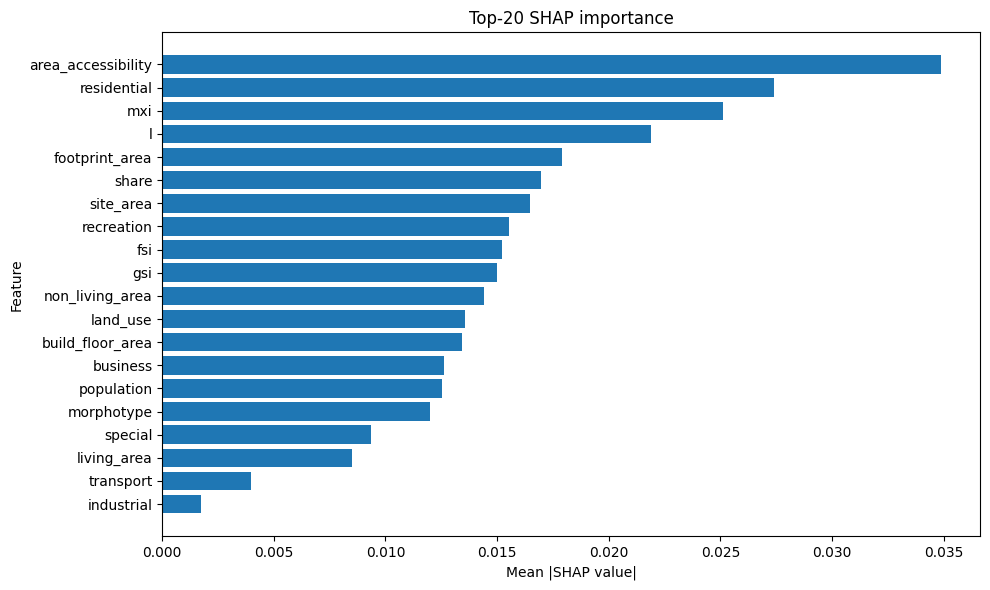

Learning rate set to 0.03152
0:	learn: 0.1524891	total: 599us	remaining: 599ms
100:	learn: 0.1071789	total: 81.8ms	remaining: 728ms
200:	learn: 0.0870926	total: 131ms	remaining: 519ms
300:	learn: 0.0691778	total: 181ms	remaining: 420ms
400:	learn: 0.0566069	total: 234ms	remaining: 350ms
500:	learn: 0.0456517	total: 289ms	remaining: 288ms
600:	learn: 0.0369413	total: 347ms	remaining: 231ms
400:	learn: 0.0566069	total: 234ms	remaining: 350ms
500:	learn: 0.0456517	total: 289ms	remaining: 288ms
600:	learn: 0.0369413	total: 347ms	remaining: 231ms
700:	learn: 0.0308464	total: 441ms	remaining: 188ms
800:	learn: 0.0259109	total: 514ms	remaining: 128ms
900:	learn: 0.0217486	total: 566ms	remaining: 62.2ms
999:	learn: 0.0186573	total: 621ms	remaining: 0us
700:	learn: 0.0308464	total: 441ms	remaining: 188ms
800:	learn: 0.0259109	total: 514ms	remaining: 128ms
900:	learn: 0.0217486	total: 566ms	remaining: 62.2ms
999:	learn: 0.0186573	total: 621ms	remaining: 0us


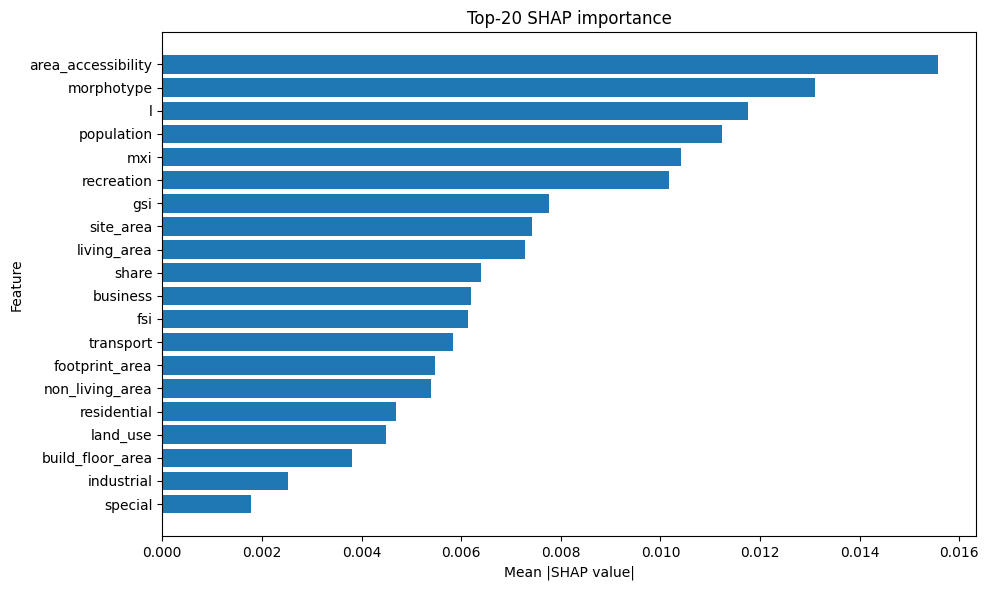

In [89]:
for prompt in prompts:
    df = blocks_evaluated[blocks_evaluated['prompt'] == prompt]
    model = CatBoostRegressor()
    target = df['output_clean'].fillna(df['output_clean'].mean())
    df = df[feature_cols]
    model.fit(df, target,cat_features=cat_features,verbose=100)
    plot_catboost_shap(model,df,top_n=20,cat_features=cat_features,)

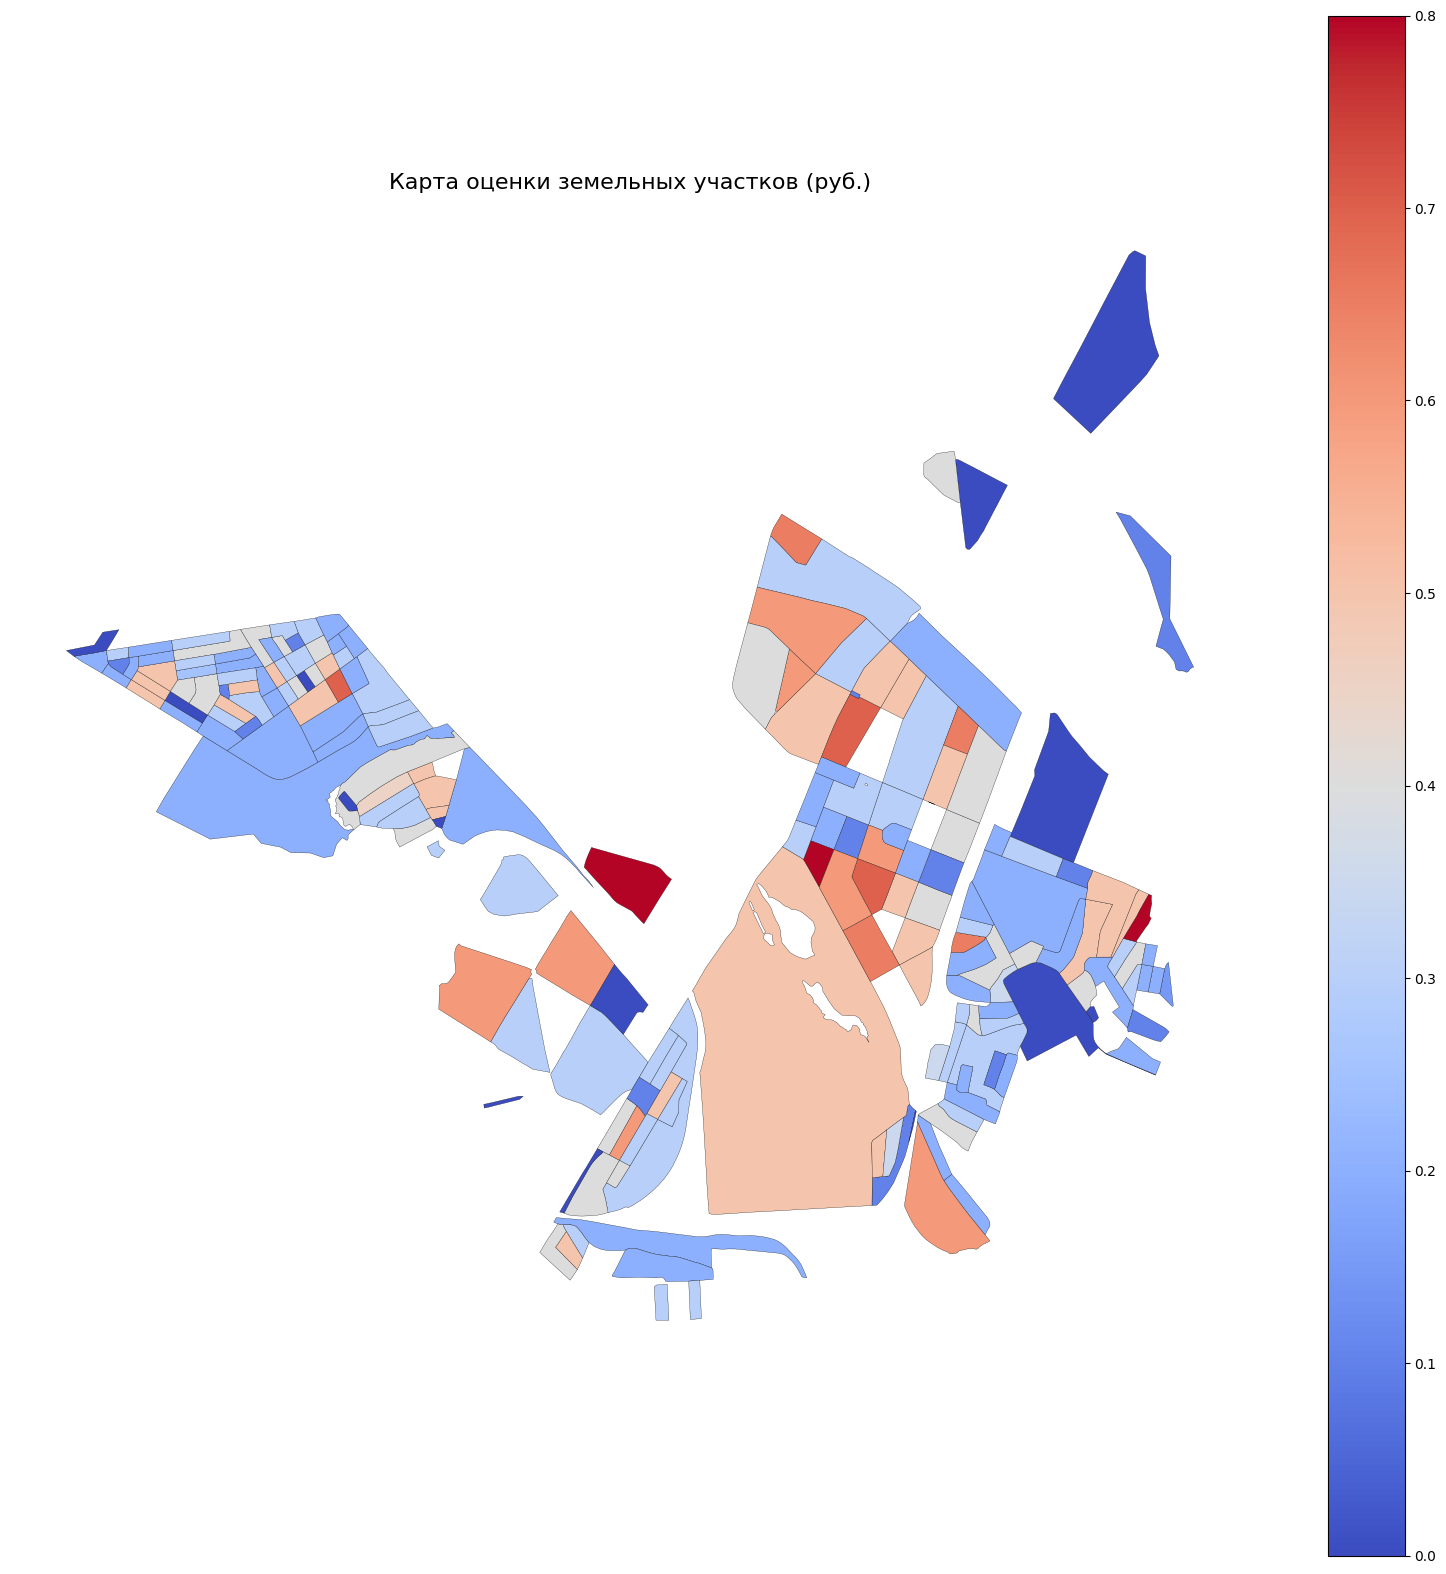

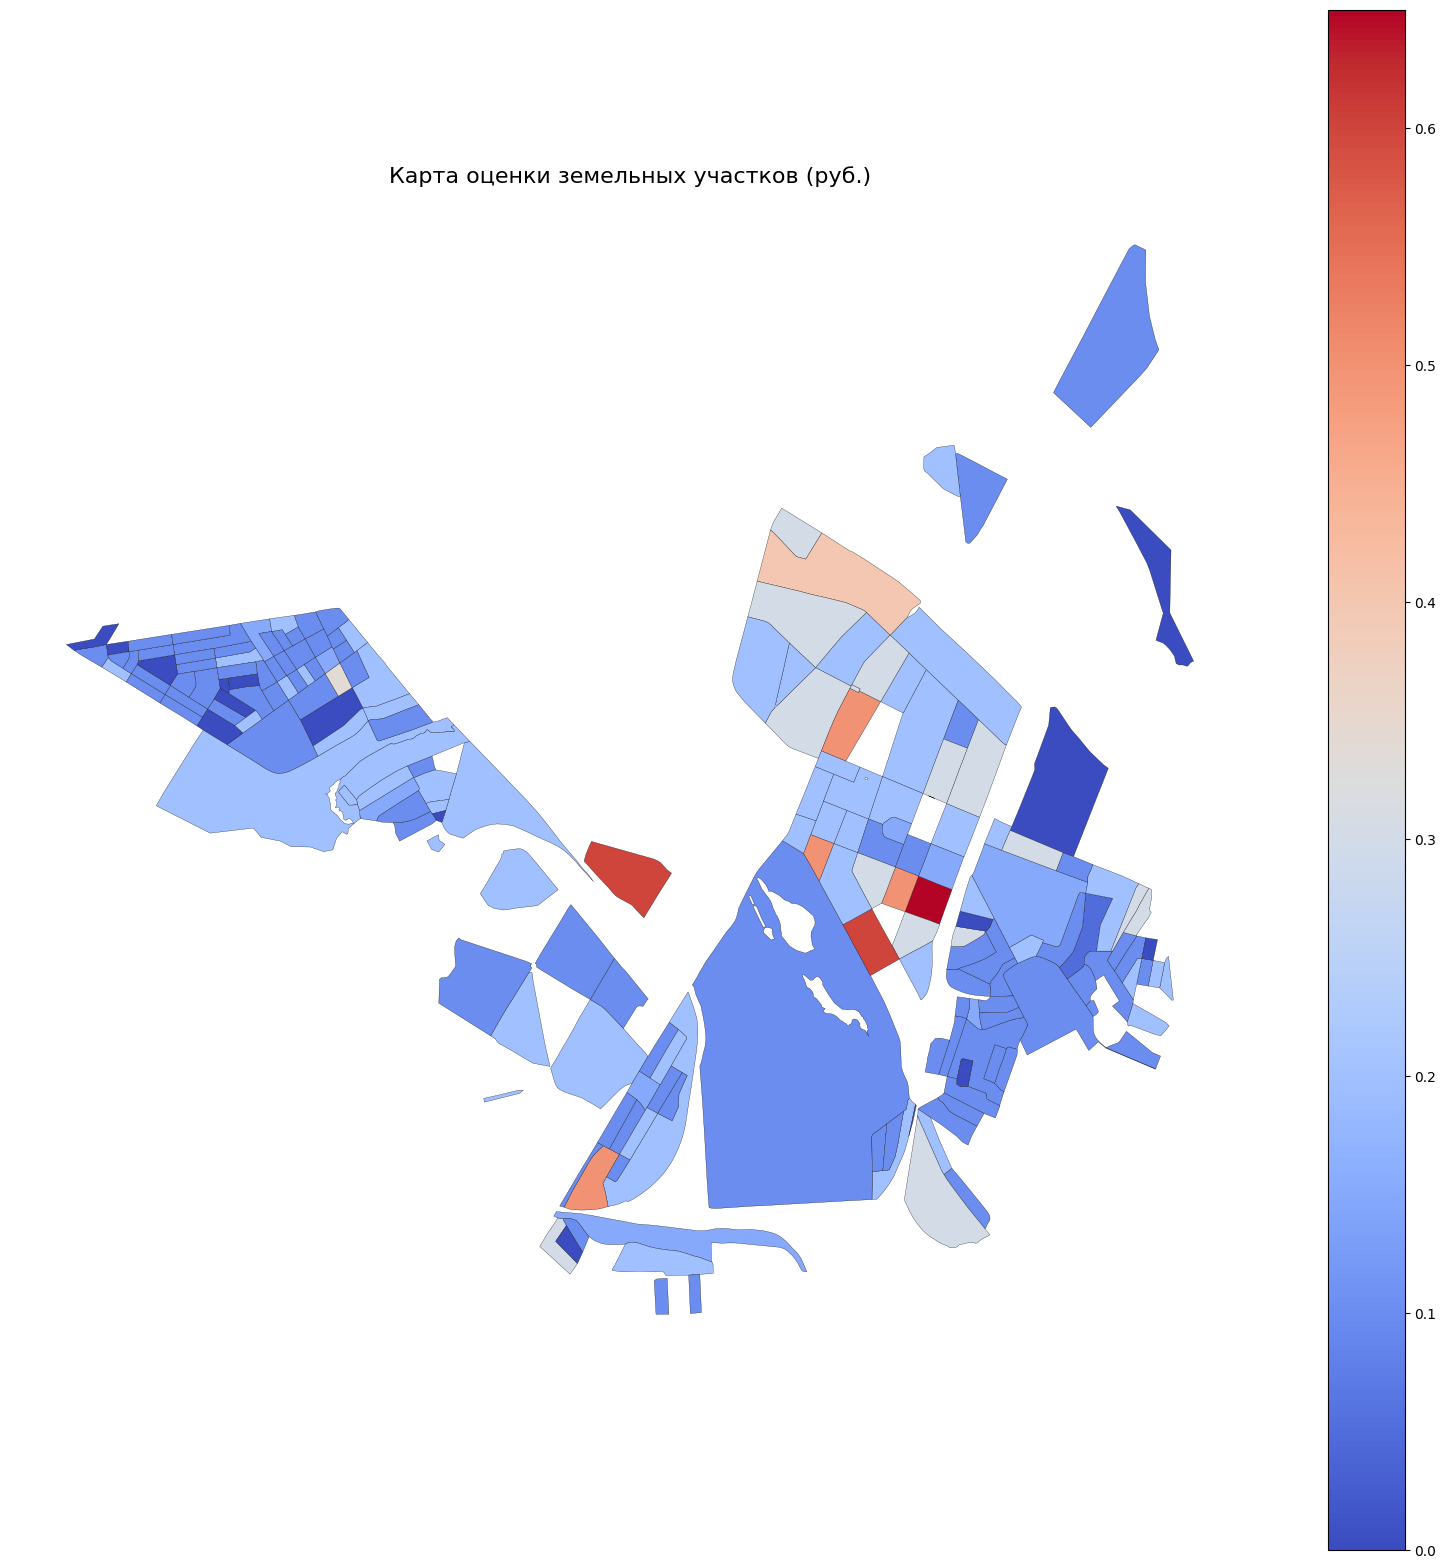

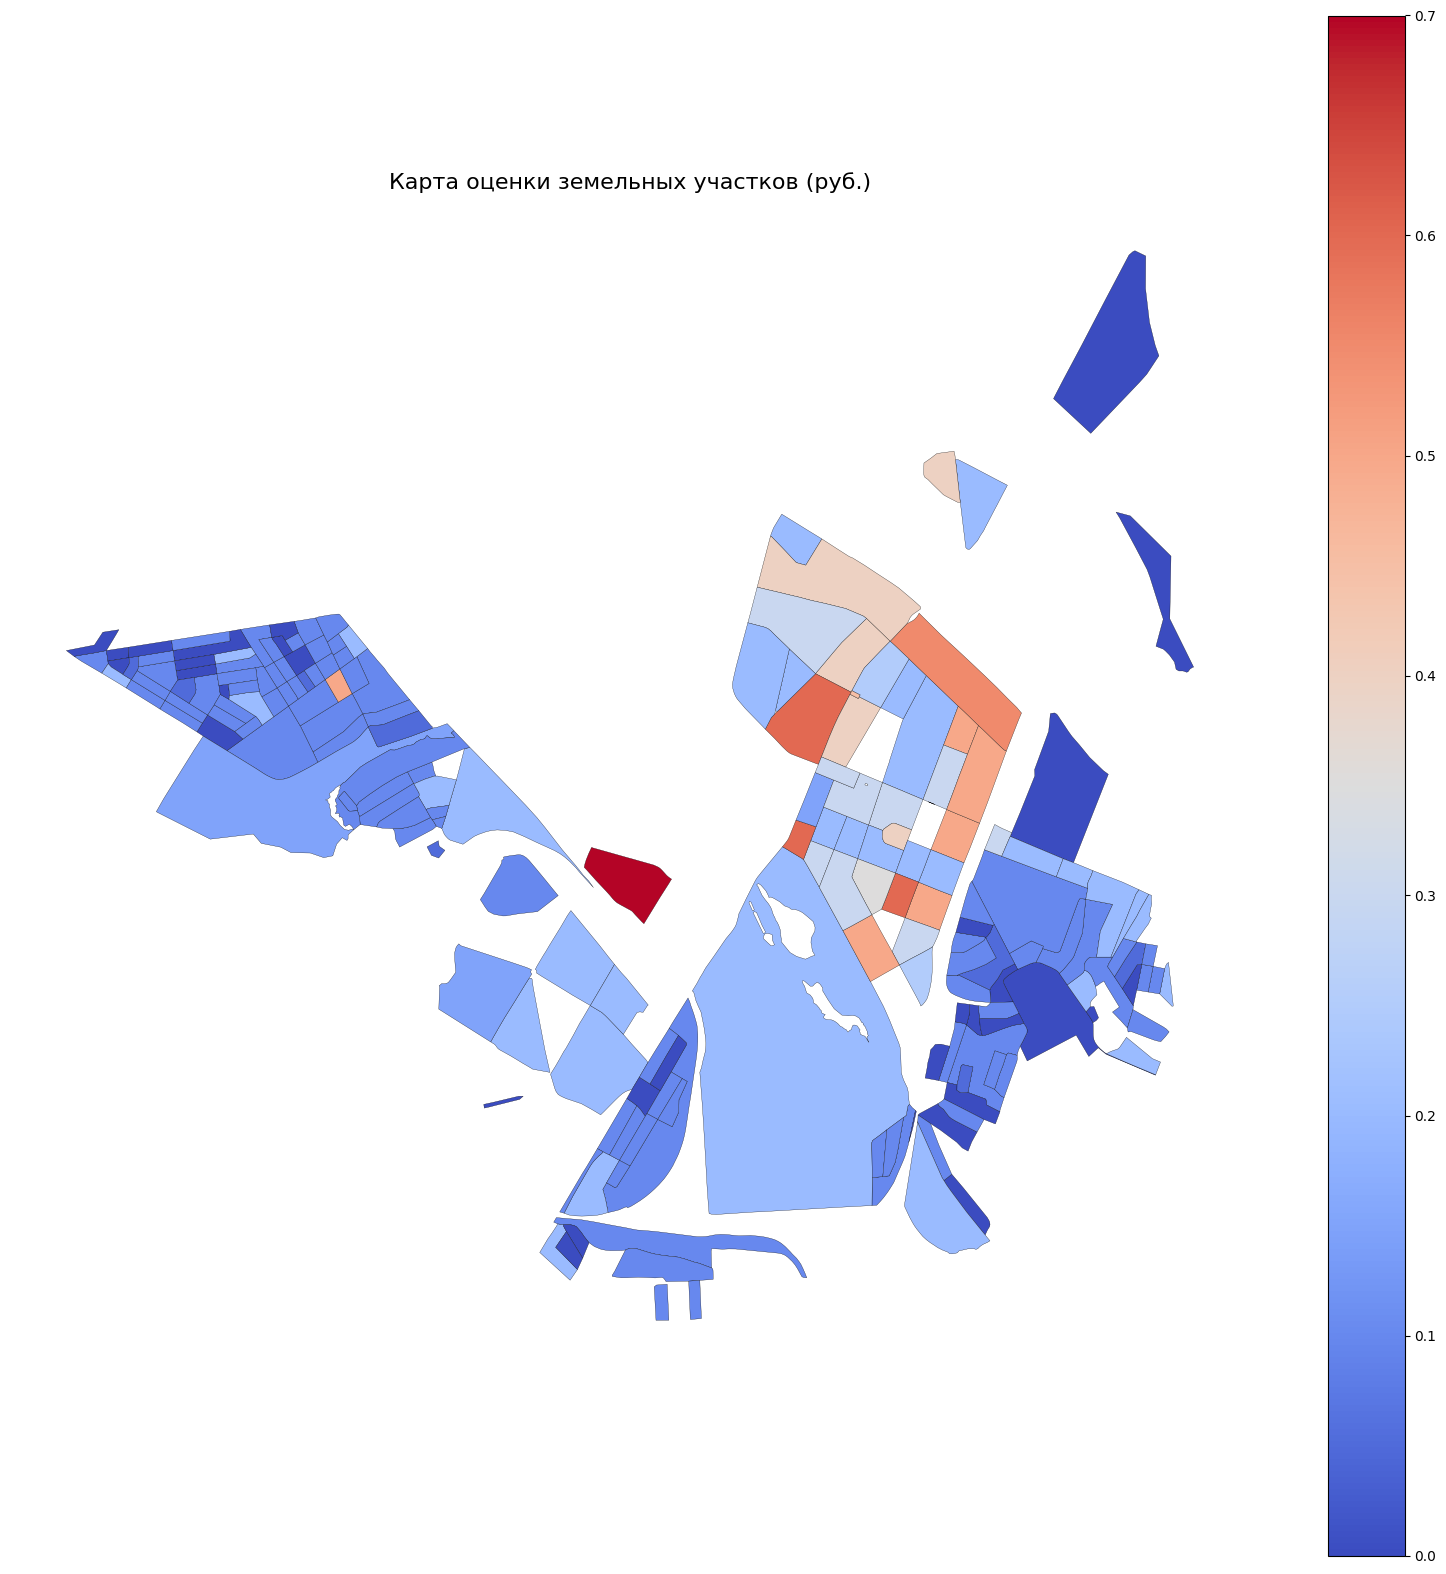

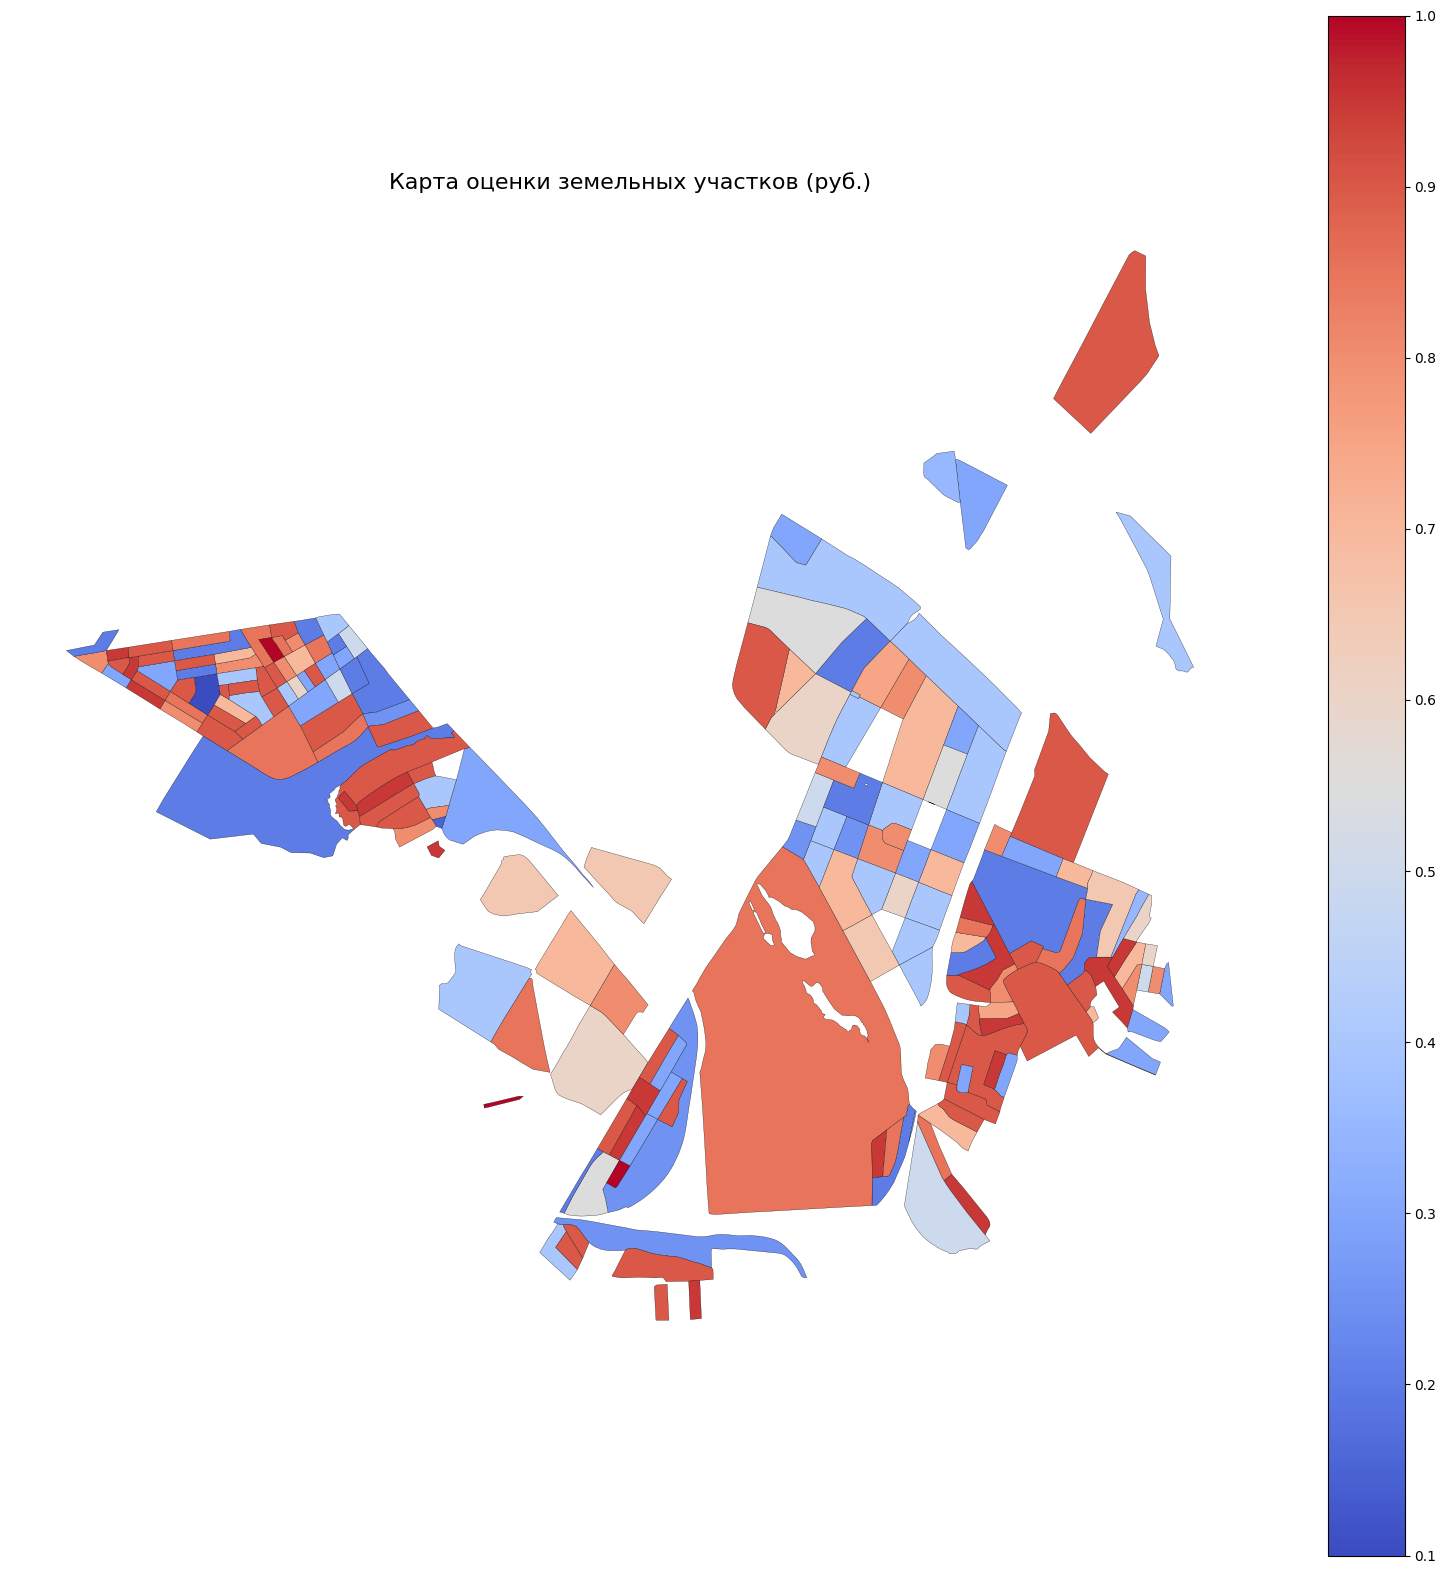

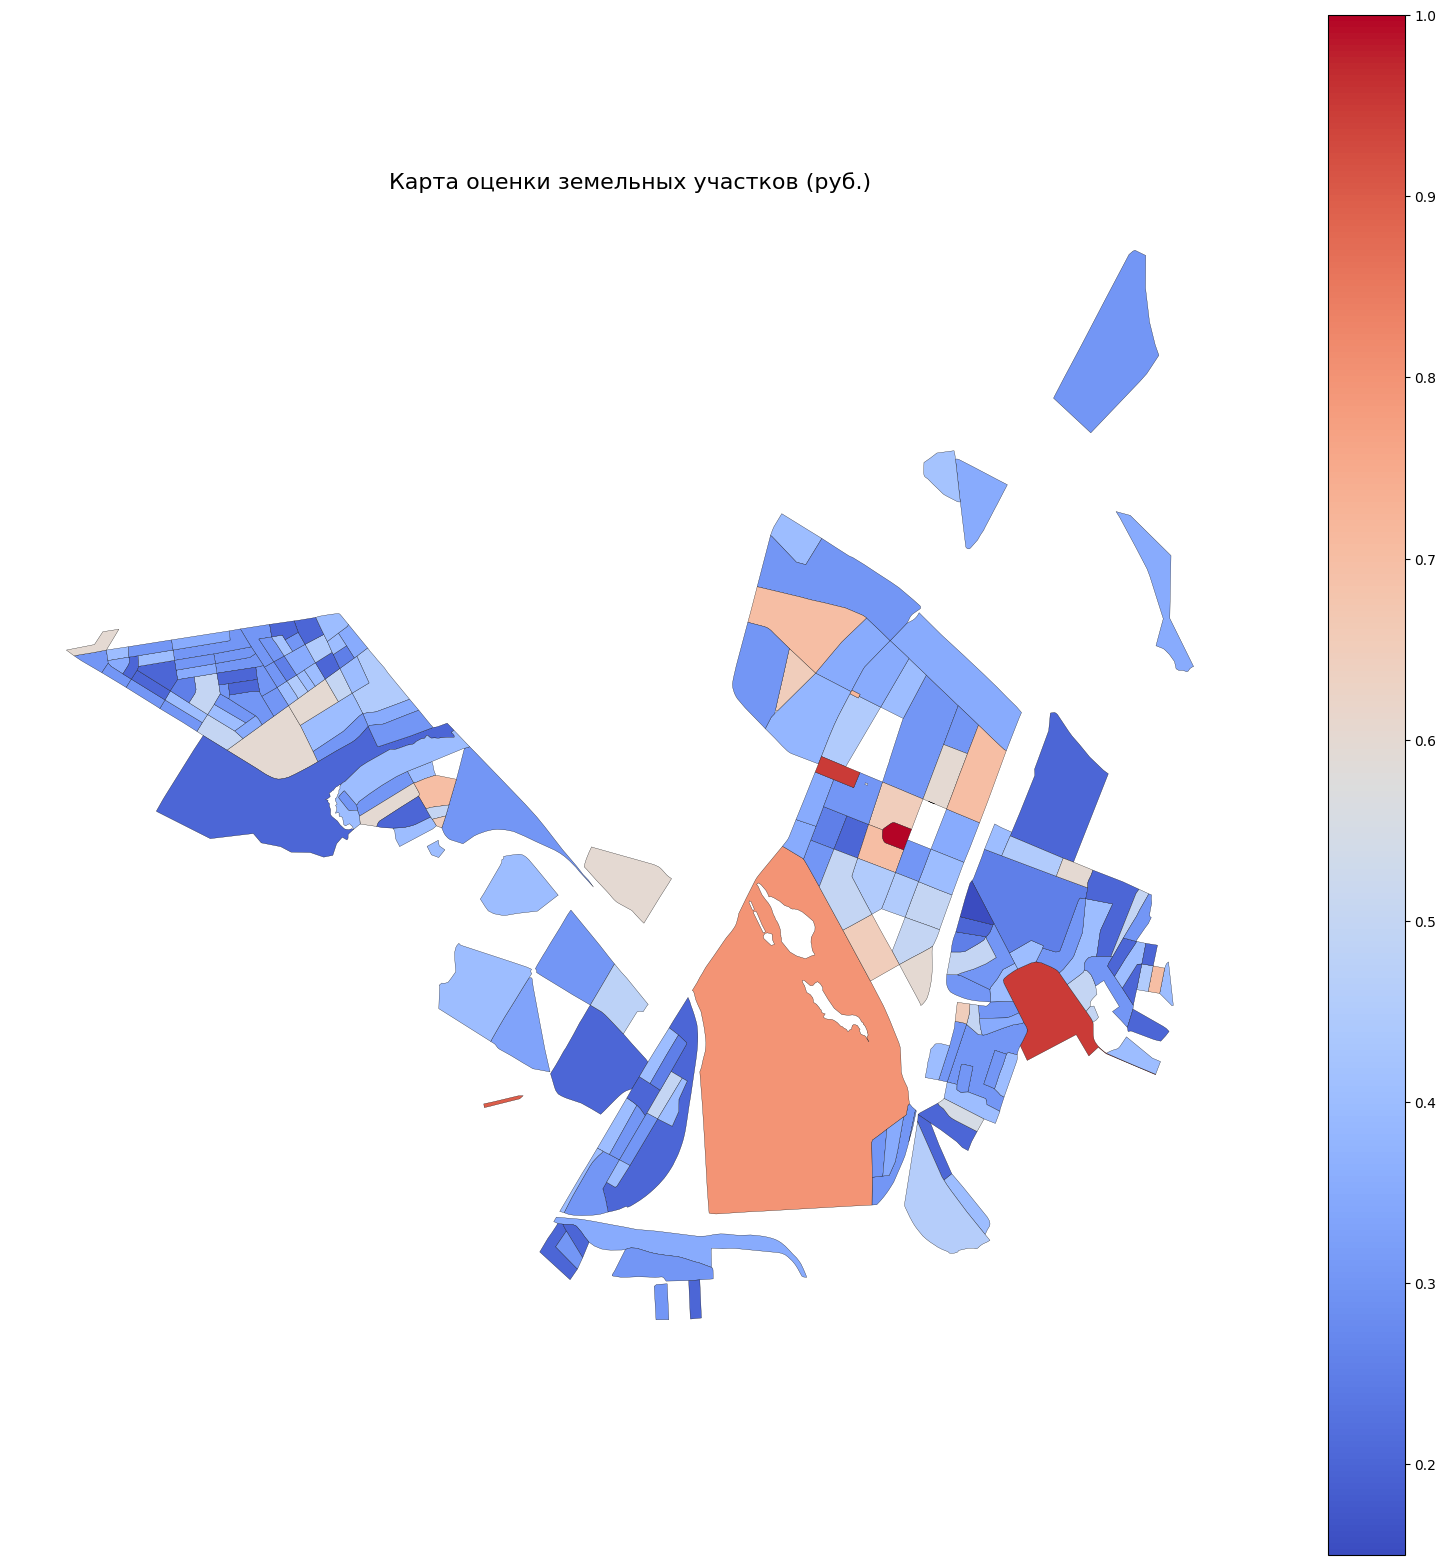

In [90]:
import matplotlib.pyplot as plt
for prompt in prompts:
    blocks_evaluated[blocks_evaluated['prompt']==prompt] \
    .plot(
        column='output_clean',
        legend=True,
        figsize=(20,20),
        cmap='coolwarm',
        edgecolor='black',   # <-- цвет границы
        linewidth=0.2        # <-- толщина границы
    ).set_axis_off()
    plt.title('Карта оценки земельных участков (руб.)', fontsize=16)

    plt.show()

# Оптимизация района

## NSGA 2

In [20]:
site_area = float(blocks_clean.loc[blocks_clean["id"] == target_id, "site_area"].iloc[0])

constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.1 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 10.0},
    "mxi": {"type": "float", "min": 0.1, "max": 1.0},

    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
}

from urbanomy.methods.land_value_modeling import (
    build_pareto_front_dataframe,
    run_nsga2_with_strategic_alignment,
)
from pathlib import Path
import pandas as pd

notebook_dir = Path("examples") if Path("examples/paper.ipynb").exists() else Path(".")
optimization_log_path = notebook_dir / "optimization_log.jsonl"
pareto_front_path = notebook_dir / "pareto_front.jsonl"

prompt = """
Evaluate the presented scenario based on the criterion of balancing the interests of various land users.
Analyze potential conflicts between residents, pedestrians, drivers, business owners, visitors, employees, seniors, and families with children.
Assign a score from 0 to 1.
Return only valid JSON without markdown, comments, or explanations, using this exact format:
{"score": 0.0}
""".strip()

res, problem = run_nsga2_with_strategic_alignment(
    blocks=blocks_clean,
    model=model,
    estimator_kwargs={
        "orig_features": numeric_feats + cat_features,
        "categorical_features": cat_features,
    },
    constraints=constraints,
    target_id=target_id,
    baseline=baseline,
    prompt=prompt,
    pop_size=20,
    n_gen=30,
    seed=42,
    verbose=True,
    save_history=True,
    log_optimization=True,
    optimization_log_path=optimization_log_path,
)

pareto_df = build_pareto_front_dataframe(res=res, problem=problem)
optimization_log_df = pd.DataFrame(problem.optimization_log)

pareto_df.to_json(pareto_front_path, orient="records", lines=True, force_ascii=False)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       20 |      3 |             - |             -
     2 |       40 |      4 |  0.5000000000 |         ideal
     3 |       60 |      6 |  0.0344766839 |             f
     4 |       80 |      9 |  0.1703305043 |         ideal
     5 |      100 |      8 |  0.0233942571 |         ideal
     6 |      120 |     12 |  0.0165743766 |         ideal
     7 |      140 |     13 |  0.1521537326 |         ideal
     8 |      160 |     17 |  0.1372493790 |         ideal
     9 |      180 |     17 |  0.0198906570 |         ideal
    10 |      200 |     19 |  0.0029267798 |         ideal
    11 |      220 |     18 |  0.0909090909 |         ideal
    12 |      240 |     19 |  0.1196908404 |         ideal
    13 |      260 |     20 |  0.0833333333 |         ideal
    14 |      280 |     20 |  0.0184568693 |             f
    15 |      300 |     20 |  0.0718249438 |         ideal
    16 |      320 |     20 |  0.0242484085 |         ide

In [26]:
pareto_df

,scenario_id,title,summary,land_use,land_value_after,land_value_gain,investor_npv,params_repaired,llm score,ser_alignment_reasoning
0,scenario_0,scenario_0 | RECREATION,scenario_0 | RECREATION; land_use=RECREATION; ...,RECREATION,6.365899e+10,7.074730e+08,4.529726e+09,"{'footprint_area': 25378.02934831227, 'l': 9.9...",0.80,
1,scenario_1,scenario_1 | BUSINESS,scenario_1 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.309090e+10,1.393819e+08,6.605294e+09,"{'footprint_area': 25107.42816019796, 'l': 9.9...",0.25,
2,scenario_2,scenario_2 | BUSINESS,scenario_2 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.324475e+10,2.932260e+08,6.560384e+09,"{'footprint_area': 25382.398222395932, 'l': 9....",0.20,
3,scenario_3,scenario_3 | BUSINESS,scenario_3 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.152272e+10,-1.428804e+09,6.577734e+09,"{'footprint_area': 25382.398222395932, 'l': 9....",0.30,
4,scenario_4,scenario_4 | RECREATION,scenario_4 | RECREATION; land_use=RECREATION; ...,RECREATION,6.380302e+10,8.515026e+08,2.873385e+09,"{'footprint_area': 26066.144054081913, 'l': 9....",0.45,
5,scenario_5,scenario_5 | BUSINESS,scenario_5 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.246027e+10,-4.912495e+08,4.788286e+09,"{'footprint_area': 25170.82169952541, 'l': 9.9...",0.75,
6,scenario_6,scenario_6 | RECREATION,scenario_6 | RECREATION; land_use=RECREATION; ...,RECREATION,6.377729e+10,8.257695e+08,3.043913e+09,"{'footprint_area': 25378.932439220538, 'l': 9....",0.70,
7,scenario_7,scenario_7 | RECREATION,scenario_7 | RECREATION; land_use=RECREATION; ...,RECREATION,6.374831e+10,7.967879e+08,4.477773e+09,"{'footprint_area': 26066.144054081913, 'l': 9....",0.70,
8,scenario_8,scenario_8 | INDUSTRIAL,scenario_8 | INDUSTRIAL; land_use=INDUSTRIAL; ...,INDUSTRIAL,6.295636e+10,4.837149e+06,5.219043e+09,"{'footprint_area': 25350.799635637144, 'l': 9....",0.65,
9,scenario_9,scenario_9 | BUSINESS,scenario_9 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.271597e+10,-2.355464e+08,6.063743e+09,"{'footprint_area': 25380.87049152216, 'l': 9.8...",0.35,


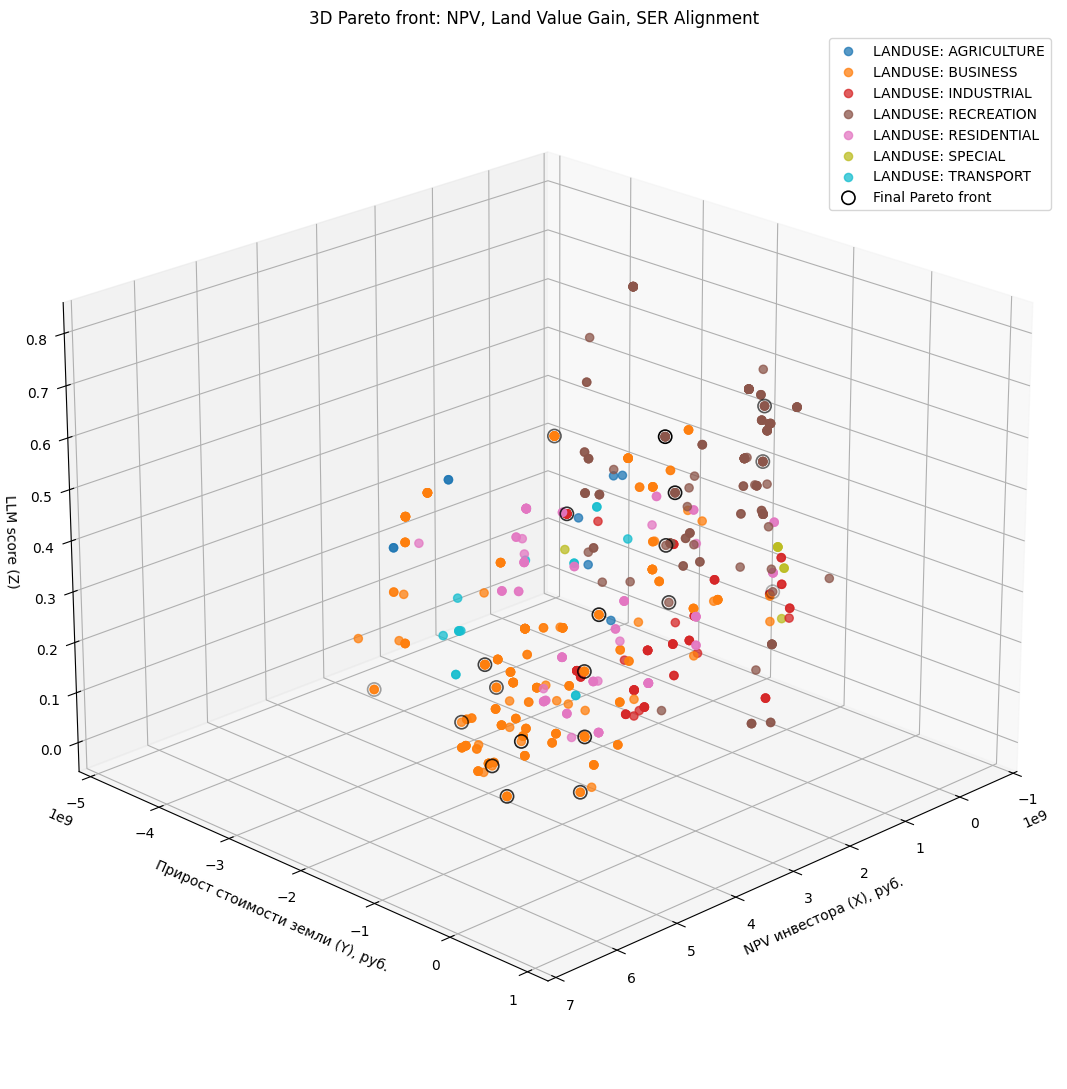

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем все решения из history, иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]
ser_score = -F[:, 2]

# 4) LANDUSE для каждого решения
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

# 6) 3D-график
fig = plt.figure(figsize=(11, 11))
ax = fig.add_subplot(111, projection="3d")

for lu in unique_lu:
    m = landuse_labels == lu
    ax.scatter(
        investor_npv[m],
        admin_gain[m],
        ser_score[m],
        s=35,
        alpha=0.75,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# 7) Отдельно выделяем финальный Pareto front из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
pf_z = -res.F[:, 2]

ax.scatter(
    pf_x,
    pf_y,
    pf_z,
    s=90,
    c="none",
    edgecolors="black",
    linewidths=1.2,
    label="Final Pareto front",
)

ax.set_xlabel("NPV инвестора (X), руб.")
ax.set_ylabel("Прирост стоимости земли (Y), руб.")
ax.set_zlabel("LLM score (Z)")
ax.set_title("3D Pareto front: NPV, Land Value Gain, SER Alignment")

ax.view_init(elev=22, azim=45)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


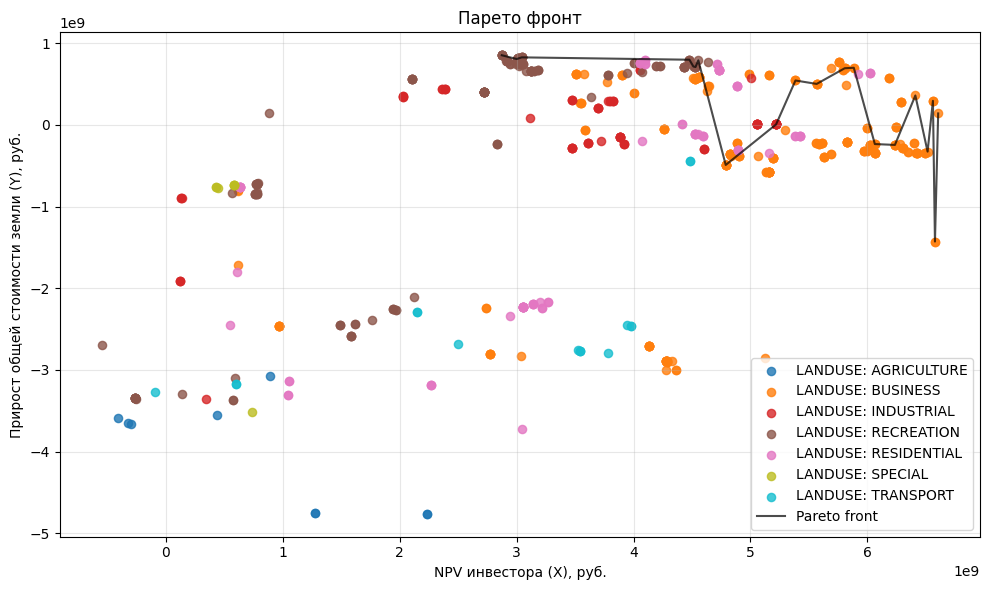

In [24]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   

## NSGA II (без LLM)

In [ ]:
from pathlib import Path

import pandas as pd
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

from urbanomy.methods.land_value_modeling import DistrictProblem, build_pareto_front_dataframe

notebook_dir = Path("examples") if Path("examples/paper.ipynb").exists() else Path(".")

problem_no_llm = DistrictProblem(
    blocks=blocks_clean,
    model=model,
    estimator_kwargs={
        "orig_features": numeric_feats + cat_features,
        "categorical_features": cat_features,
    },
    constraints=constraints,
    target_id=target_id,
    log_optimization=True,
)

algorithm = NSGA2(
    pop_size=20,
    eliminate_duplicates=True,
)

res_no_llm = minimize(
    problem_no_llm,
    algorithm,
    ('n_gen', 30),
    seed=42,
    verbose=True,
    save_history=True,
)

no_llm_log_df = pd.DataFrame(problem_no_llm.optimization_log)
no_llm_pareto_df = build_pareto_front_dataframe(
    res=res_no_llm,
    problem=problem_no_llm,
    scenario_prefix="no_llm_pareto",
)

no_llm_log_df.to_json(notebook_dir / "no_llm_optimization_log.jsonl", orient="records", lines=True, force_ascii=False)
no_llm_pareto_df.to_json(notebook_dir / "no_llm_pareto_front.jsonl", orient="records", lines=True, force_ascii=False)


In [ ]:
# idx = np.argmin(res.F[:, 0])   # максимум land_value

# params_optimal = {p: res.X[idx][i] for i, p in enumerate(problem.constraints.keys())}
# params_repaired = problem._repair_genome(params_optimal)

# metrics = {
#     "params_repaired": params_repaired,
#     "land_value_after": float(-res.F[idx, 0]),
#     "land_value_gain": float(-res.F[idx, 0] - baseline_land_value),
#     "investor_npv": float(-res.F[idx, 1]),
# }
metrics

{'params_repaired': {'footprint_area': 20297.073203890784,
  'l': 4.949905957768471,
  'mxi': 0.1433118074895298,
  'residential': 0.17913975936191223,
  'business': 0.02419225822653892,
  'recreation': 0.2506176739074939,
  'industrial': 0.19552141390717886,
  'transport': 0.20192404099774872,
  'special': 0.032909804252761424,
  'agriculture': 0.11569504934636592,
  'share': 0.17913975936191223,
  'land_use': <LandUse.RECREATION: 'recreation'>,
  'build_floor_area': 100468.60357720178,
  'living_area': 14398.337174597826,
  'non_living_area': 86070.26640260396,
  'population': 719.9168587298913,
  'fsi': 0.3831009655798107,
  'gsi': 0.07739560485559634,
  'morphotype': 'mid-rise non-residential'},
 'land_value_after': 59853915457.40738,
 'land_value_gain': -3097604456.281555,
 'investor_npv': 594080323.95}

In [ ]:
idx = np.argmin(res.F[:, 1])   # максимум land_value

params_optimal = {p: res.X[idx][i] for i, p in enumerate(problem.constraints.keys())}
params_repaired = problem._repair_genome(params_optimal)

metrics = {
    "params_repaired": params_repaired,
    "land_value_after": float(-res.F[idx, 0]),
    "land_value_gain": float(-res.F[idx, 0] - baseline_land_value),
    "investor_npv": float(-res.F[idx, 1]),
}
metrics

{'params_repaired': {'footprint_area': 19880.925259507625,
  'l': 9.494335591247054,
  'mxi': 0.21382131965569076,
  'residential': 0.26727664956961344,
  'business': 0.13987544747428557,
  'recreation': 0.05824784619830459,
  'industrial': 0.13967156657907198,
  'transport': 0.1481938261292359,
  'special': 0.04617288463916512,
  'agriculture': 0.20056177941032333,
  'share': 0.26727664956961344,
  'land_use': <LandUse.RESIDENTIAL: 'residential'>,
  'build_floor_area': 188756.17627826583,
  'living_area': 40360.09470498099,
  'non_living_area': 148396.08157328484,
  'population': 2018.0047352490496,
  'fsi': 0.7197539411980611,
  'gsi': 0.07580877400853739,
  'morphotype': 'high-rise soviet microdistrict'},
 'land_value_after': 59941461654.58095,
 'land_value_gain': -3010058259.1079865,
 'investor_npv': 2620941337.21}

Изменение стоимости земли по всем кварталам:
 • Сумма до:    62 951 519 914 ₽
 • Сумма после: 59 941 461 655 ₽
 • Изм.  ₽:     -3 010 058 259 ₽
 • Изм., %:     -4.78%

Изменяемый квартал:
 • До: 590 959 314 ₽ | После: 744 210 221 ₽ | Δ: +153 250 907 ₽ | Δ%: +25.93%


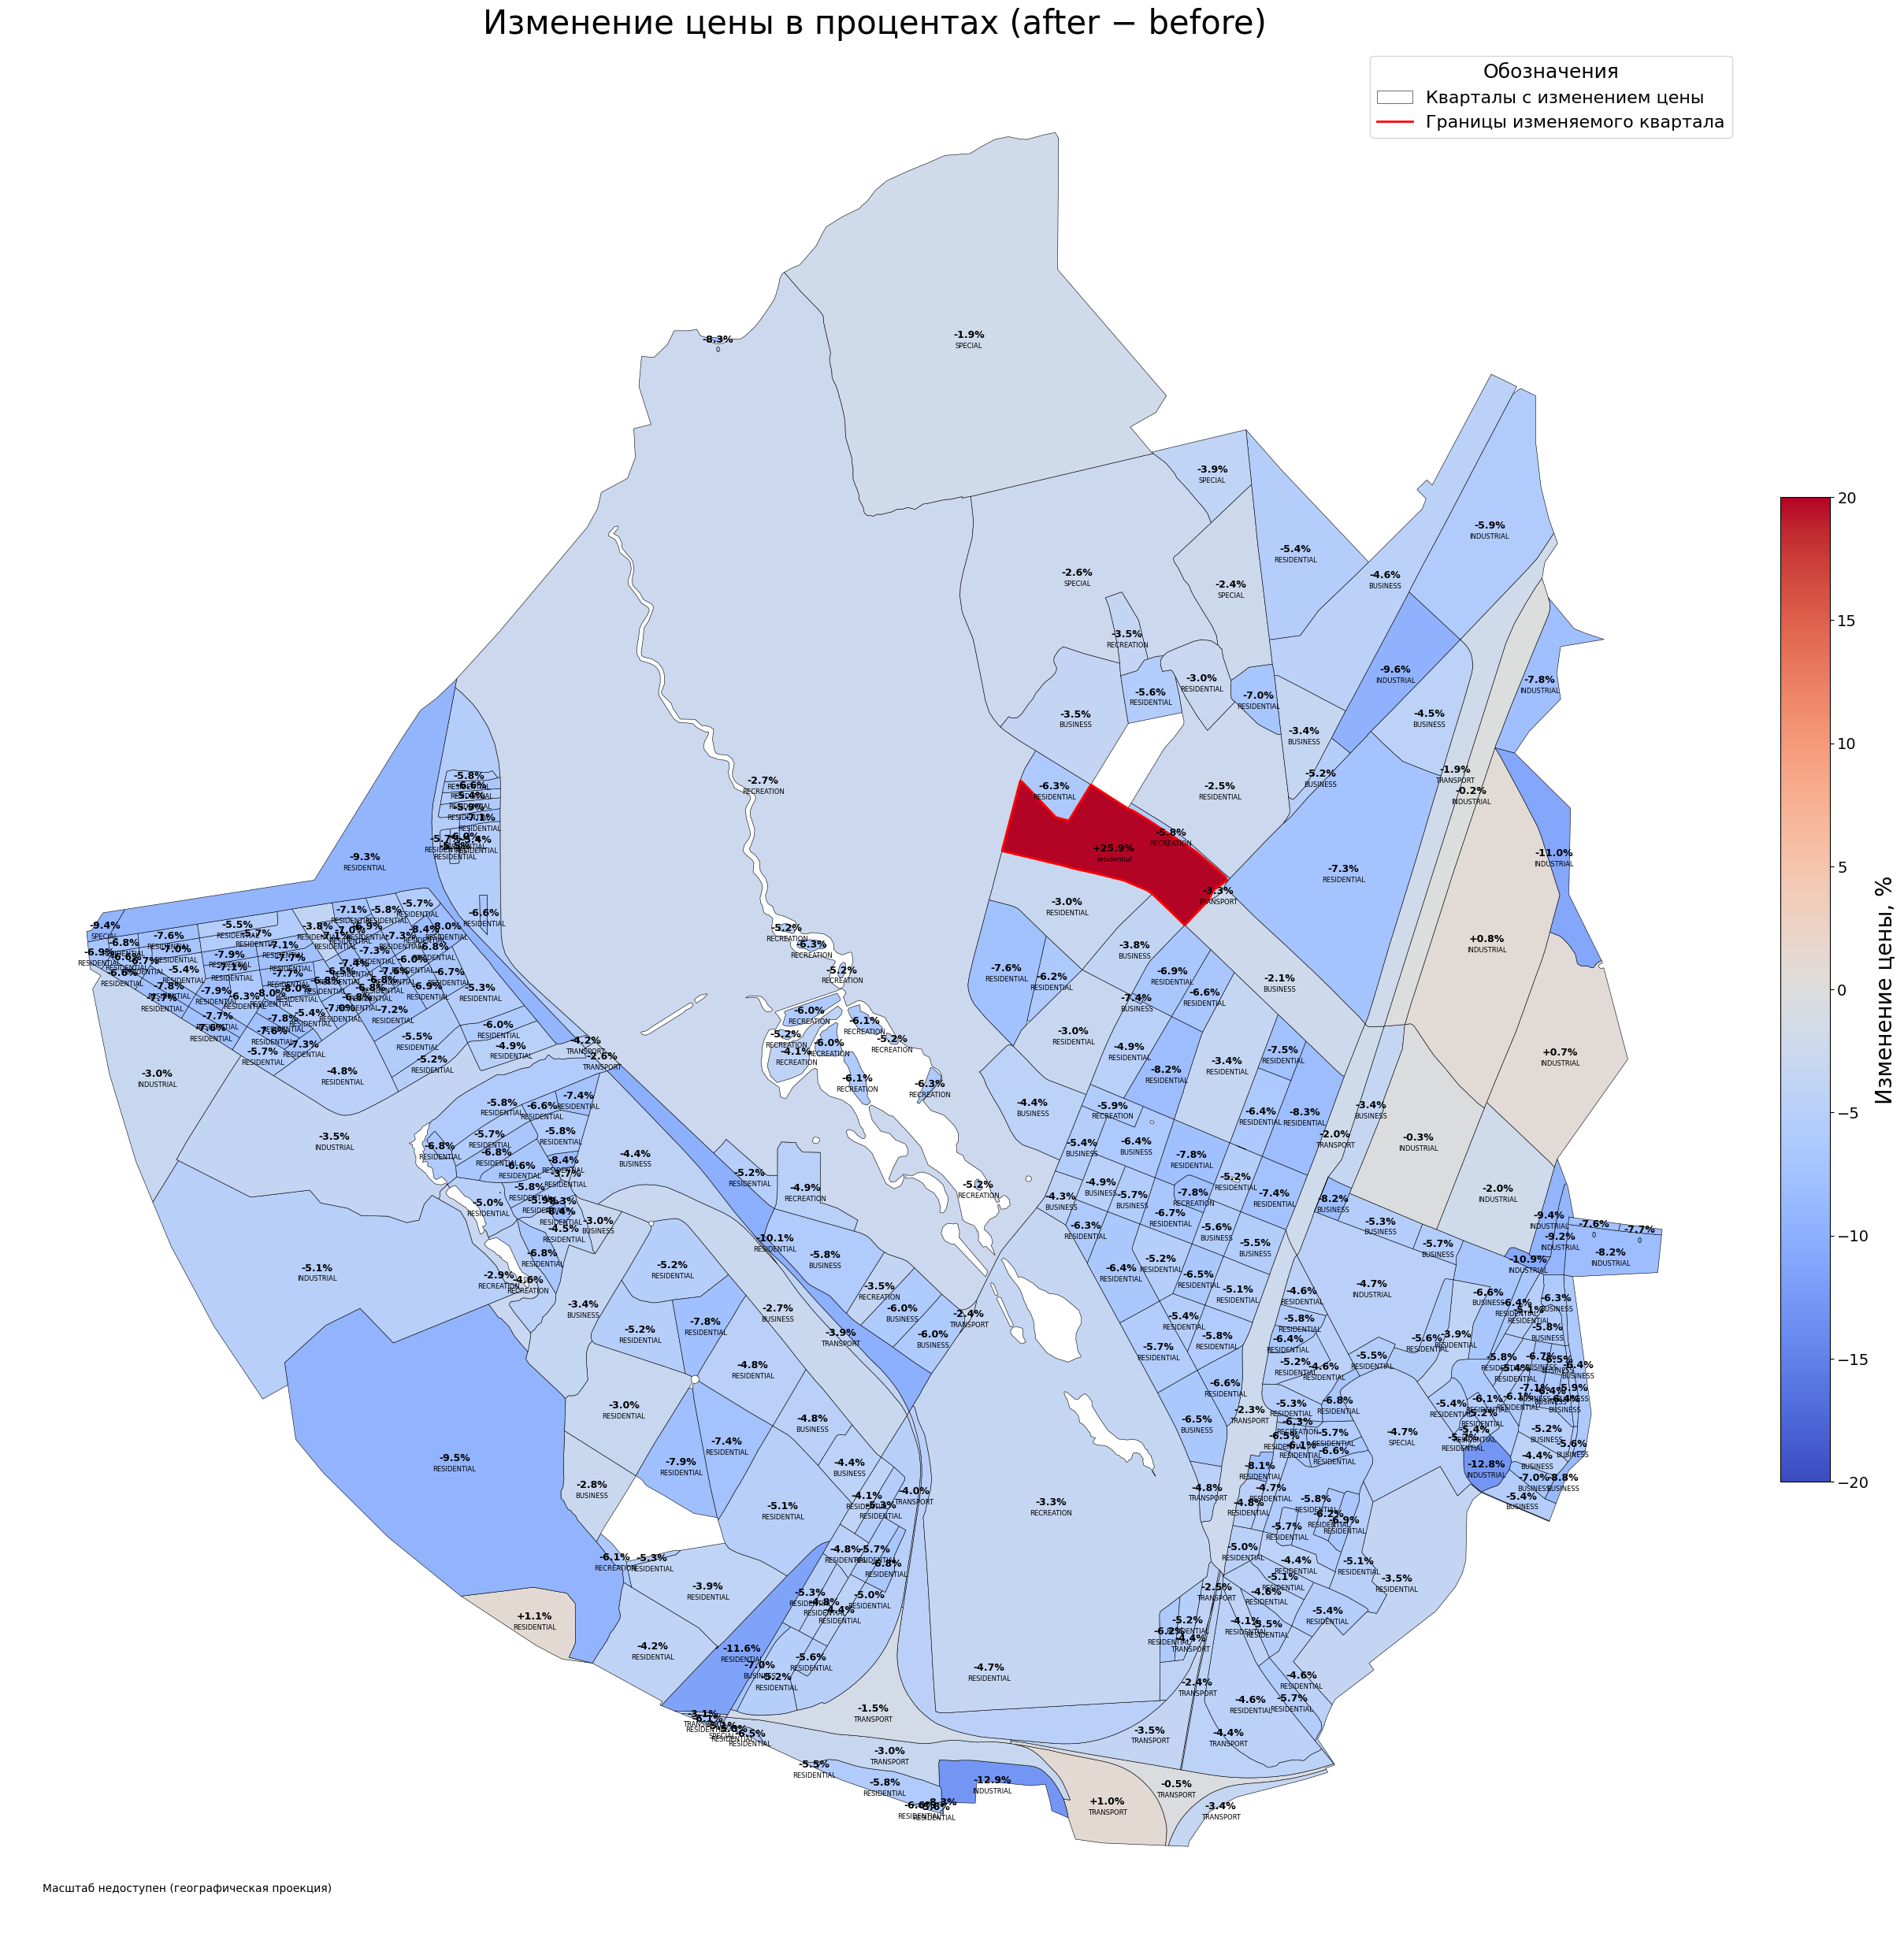

In [ ]:
import numpy as np
import pandas as pd

from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    LandPriceEstimator,
    plot_scenario_impact,
)


# Базовые кварталы должны быть теми же, что использовал оптимизатор
blocks_before = problem.blocks.copy()

# Помечаем проектный квартал
blocks_before["is_project"] = False
blocks_before.loc[blocks_before["id"] == target_id, "is_project"] = True

# 1) Применяем оптимизационный сценарий к базовым кварталам
modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_id, params_repaired)
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_id, "is_project"] = True

# 2) Считаем стоимость "до" и "после" тем же способом, что и в DistrictProblem
estimator_kwargs = dict(
    model=problem.model,
    orig_features=problem.estimator_kwargs["orig_features"],
    categorical_features=problem.estimator_kwargs["categorical_features"],
    use_service_features=False,
)

baseline_estimator = LandPriceEstimator(
    blocks=blocks_before,
    **estimator_kwargs,
)
blocks_before_pred = baseline_estimator.predict()

scenario_estimator = LandPriceEstimator(
    blocks=blocks_after,
    **estimator_kwargs,
)
blocks_after_pred = scenario_estimator.predict()

for df in (blocks_before_pred, blocks_after_pred):
    df["land_value_per_100m2"] = np.where(
        pd.to_numeric(df["site_area"], errors="coerce") > 0,
        pd.to_numeric(df["land_value"], errors="coerce")
        / pd.to_numeric(df["site_area"], errors="coerce") * 100,
        np.nan,
    )

baseline_cols = blocks_before_pred[
    ["id", "land_value", "land_value_per_100m2"]
].rename(
    columns={
        "land_value": "land_value_before",
        "land_value_per_100m2": "land_value_before_per_100m2",
    }
)

blocks_full_value = blocks_after_pred.merge(
    baseline_cols,
    on="id",
    how="left",
    validate="one_to_one",
)

blocks_full_value["d_rub"] = (
    blocks_full_value["land_value"] - blocks_full_value["land_value_before"]
)

blocks_full_value["land_value_delta_pct"] = np.where(
    pd.to_numeric(blocks_full_value["land_value_before"], errors="coerce") > 0,
    (blocks_full_value["land_value"] / blocks_full_value["land_value_before"] - 1.0) * 100,
    np.nan,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)

sum_before = float(blocks_full_value["land_value_before"].sum())
sum_after = float(blocks_full_value["land_value"].sum())
sum_delta = sum_after - sum_before
sum_delta_pct = (sum_after / sum_before - 1.0) * 100 if sum_before > 0 else np.nan

print("Изменение стоимости земли по всем кварталам:")
print(f" • Сумма до:    {sum_before:,.0f} ₽".replace(",", " "))
print(f" • Сумма после: {sum_after:,.0f} ₽".replace(",", " "))
print(f" • Изм., ₽:     {sum_delta:+,.0f} ₽".replace(",", " "))
print(f" • Изм., %:     {sum_delta_pct:+.2f}%")

target_row = blocks_full_value.loc[blocks_full_value["id"] == target_id].iloc[0]
print("\nИзменяемый квартал:")
print(
    f" • До: {target_row['land_value_before']:,.0f} ₽ | "
    f"После: {target_row['land_value']:,.0f} ₽ | "
    f"Δ: {target_row['d_rub']:+,.0f} ₽ | "
    f"Δ%: {target_row['land_value_delta_pct']:+.2f}%".replace(",", " ")
)

scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_id,
    target_id_column="id",
    print_summary=False,
    print_quarter_stats=False,
    figsize=(25, 35),
)
